# **Segmentasi Musik Spotify Berbasis Audio Features Menggunakan K-Means Clustering**

---

## **Latar Belakang Masalah**

Industri musik digital mengalami pertumbuhan eksponensial dengan jutaan lagu tersedia di platform streaming seperti Spotify. Tantangan utama yang dihadapi adalah cara **mengorganisir dan mengkategorikan lagu-lagu** tersebut secara efektif untuk meningkatkan pengalaman pengguna melalui sistem rekomendasi yang personal.

Pendekatan tradisional menggunakan genre musik memiliki keterbatasan karena:
- Genre seringkali **subjektif** dan saling **tumpang tindih**
- Satu lagu dapat memiliki karakteristik dari beberapa genre
- Label genre tidak menangkap nuansa audio yang sebenarnya

Oleh karena itu, pendekatan berbasis **audio features** (karakteristik audio numerik) menjadi solusi yang lebih objektif dan terukur.

---

## **Mengapa K-Means Clustering?**

Pemilihan algoritma **K-Means** untuk proyek ini didasarkan pada beberapa alasan teknis:

| Aspek | Penjelasan |
|-------|------------|
| **Efisiensi Komputasi** | Kompleksitas O(N × K × I × D) dimana N=jumlah data, K=cluster, I=iterasi, D=dimensi. Sangat efisien untuk dataset besar (114K+ baris) |
| **Karakteristik Data Audio** | Fitur audio Spotify (danceability, energy, valence, dll) bersifat **continuous** dan **numeric**, cocok dengan asumsi K-Means yang berbasis jarak Euclidean |
| **Interpretabilitas** | Centroid cluster mudah diinterpretasi sebagai "profil musik" yang representatif |
| **Scalability** | Dapat di-scale dengan mudah menggunakan Mini-Batch K-Means jika data bertambah besar |

### **Perbandingan dengan Algoritma Lain**

| Kriteria | K-Means | Hierarchical | DBSCAN |
|----------|---------|--------------|--------|
| **Efisiensi** | O(N×K×I×D) - Sangat cepat | O(N²) - Terlalu lambat untuk 114K data | O(N log N) - Moderat |
| **Scalability** | Mudah di-scale untuk jutaan lagu | Tidak praktis untuk data besar | Bisa di-scale dengan optimasi |
| **Interpretability** | Centroid = profil rata-rata musik | Dendrogram jelas | Sulit jelaskan ke non-teknis |
| **Convergence** | Dijamin konvergen ke local minimum | Deterministik | Sensitif parameter epsilon |
| **Cluster Shape** | Spherical/Convex | Any shape | Any shape, deteksi noise |

**Trade-off yang Dipahami:**
- Sensitif terhadap outlier → diatasi dengan **scaling & PCA**
- Asumsi cluster spherical → cocok dengan data audio yang terdistribusi normal
- Perlu tentukan K di awal → diatasi dengan **Composite Score method**

---

## **Teknik Preprocessing: Yeo-Johnson Transformation**

> **Catatan Penting**: Dalam proyek ini, kita menggunakan PowerTransformer dengan metode Yeo-Johnson untuk menormalkan distribusi data audio.

### **Mengapa PowerTransformer?**

**Perbandingan Teknik Normalisasi:**

| Teknik | Pros | Cons | Pilihan? |
|--------|------|------|----------|
| **Log Transform** | Simple, cepat | Tidak bisa handle nilai ≤ 0 | Loudness negatif |
| **Box-Cox** | Robust, cepat | Tidak bisa handle nilai ≤ 0 | Sama |
| **Yeo-Johnson** | Handle nilai negatif & positif, Robust | Sedikit lebih lambat | **DIPILIH** |

**Cara Kerja Yeo-Johnson:**

Untuk setiap fitur X:
1. Cari λ (lambda) optimal yang membuat distribusi paling mendekati normal
2. Transformasi X dengan formula yang bergantung pada nilai X dan λ
3. Standardize: `(X - mean) / std`

**Parameter `standardize=True`:**
- Otomatis lakukan StandardScaler setelah transform
- Output: mean = 0, std = 1
- **Alasan:** K-Means butuh fitur dengan skala sama

**Mengapa K-Means butuh data terdistribusi normal?**
- K-Means menggunakan **mean** (rata-rata) sebagai centroid
- Mean sensitif terhadap outlier & skewness
- Jarak Euclidean lebih akurat pada distribusi simetris

---

## **Tujuan Proyek**

1. Melakukan segmentasi lagu berdasarkan audio features menggunakan K-Means Clustering
2. Menemukan jumlah cluster optimal dengan pendekatan Composite Score yang menyeimbangkan metrik matematis dan business value
3. Membuat profil karakteristik setiap cluster musik yang terbentuk
4. Memvalidasi hasil clustering dengan membandingkan terhadap genre asli

> **Filosofi Proyek**: Kita mencari keseimbangan antara skor matematis yang optimal dan business value yang praktis. Cluster yang terlalu sedikit kurang informatif, sedangkan terlalu banyak sulit dikelola.

---

## **Tahapan Analisis**

Proyek ini mengikuti tahapan standar machine learning pipeline:

| No | Tahap | Deskripsi | Alasan |
|----|-------|-----------|--------|
| 1 | **Deskripsi Dataset** | Load data, memahami struktur | Wajib memahami data sebelum preprocessing |
| 2 | **Simple EDA** | Distribusi, korelasi, outlier | Menentukan strategi preprocessing yang tepat |
| 3 | **Preprocessing** | PowerTransformer, Scaling | K-Means butuh data ter-scale dan normal |
| 4 | **Dimensionality Reduction** | PCA 80%+ variance | Mengurangi noise, mempercepat clustering |
| 5 | **Modelling Cluster** | K-Means + Composite Score | K optimal seimbangkan metrik & business value |
| 6 | **Post-Clustering Analysis** | Profiling, Visualisasi, Validasi | Interpretasi untuk actionable insights |

# **BAGIAN 1: Data Loading & Cleaning**

## **Alasan Tahap Ini:**

Sebelum melakukan analisis apapun, kita harus:
1. Memastikan data berhasil dimuat
2. Memahami struktur dataset (baris, kolom, tipe data)
3. Mengidentifikasi masalah awal (missing values, duplikat)

**Prinsip:** "Garbage in, garbage out" - data berkualitas buruk = hasil buruk

---

## **1.1 Load Dataset dari Kaggle**

### **Alasan Menggunakan kagglehub:**

- [+] Otomatis download versi terbaru dataset
- [+] Tidak perlu manual download & upload
- [+] Reproducible - siapa pun bisa jalankan kode yang sama

### **Alternatif yang Tidak Dipilih:**

- [-] Manual download → tidak reproducible
- [-] Upload ke Google Drive → dependency eksternal

### **Informasi Dataset:**

- **Platform:** Kaggle
- **Nama:** Spotify Tracks Dataset (maharshipandya)
- **Ukuran:** 114,000+ track records
- **Format:** CSV

In [219]:
# Import Library yang Diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Semua library berhasil diimpor!")
print("PowerTransformer (Yeo-Johnson) untuk normalisasi data")

Semua library berhasil diimpor!
PowerTransformer (Yeo-Johnson) untuk normalisasi data


## **1.1 Load Dataset**

Memuat dataset Spotify Tracks dari Kaggle menggunakan `kagglehub`.

In [220]:
try:
    # Install dependencies as needed:
    # pip install kagglehub[pandas-datasets]
    import kagglehub
    from kagglehub import KaggleDatasetAdapter

    # Set the path to the file you'd like to load
    file_path = "dataset.csv"

    # Load the latest version
    df = kagglehub.load_dataset(
      KaggleDatasetAdapter.PANDAS,
      "maharshipandya/-spotify-tracks-dataset",
      file_path,
    )
    print("Data berhasil dimuat!")
except FileNotFoundError:
    print("File tidak ditemukan. Pastikan file dataset.csv ada di direktori yang sama.")

Data berhasil dimuat!


In [221]:
# Lihat 5 baris pertama
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## **1.2 Eksplorasi Struktur Data**

### **Mengapa .info() penting?**

```python
df.info()
```

- Melihat **tipe data** (numeric vs object) → menentukan fitur mana yang bisa di-cluster
- Mendeteksi **missing values** → menentukan strategi handling
- Melihat **memory usage** → estimasi performa

### **Mengapa .describe() penting?**

```python
df.describe()
```

- Melihat **distribusi statistik** (mean, std, min, max)
- Mendeteksi **outlier** ekstrem (nilai tidak masuk akal)
- Memahami **range nilai** → menentukan scaling method

In [222]:
# Informasi dataset
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"\nDimensi Dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom\n")
print("-" * 60)
df.info()

INFORMASI DATASET

Dimensi Dataset: 114,000 baris x 21 kolom

------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float6

In [223]:
# Statistik deskriptif
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## **1.3 Data Cleaning**

### **Menghapus Duplikat berdasarkan `track_id`**

**Alasan:**
- `track_id` = unique identifier lagu
- Duplikat = data redundant → bias hasil clustering
- **Prinsip:** Setiap observasi harus unique untuk analisis yang valid

**Keputusan:** Drop duplikat dengan `keep='first'` → pertahankan entry pertama, buang sisanya

### **Fitur-Fitur dalam Dataset**

Dataset ini memiliki 2 kategori fitur utama:

#### **1. Metadata Lagu (Informasi Deskriptif)**

- `track_id`: Identifier unik untuk setiap lagu
- `track_name`: Judul lagu
- `artists`: Nama artis/penyanyi
- `album_name`: Nama album
- `track_genre`: Label genre musik (untuk validasi)
- `explicit`: Status konten eksplisit (boolean)

#### **2. Audio Features (Fitur Numerik untuk Clustering)**

| Fitur | Rentang | Deskripsi | Relevansi Clustering |
|-------|---------|-----------|---------------------|
| **danceability** | 0.0 - 1.0 | Seberapa cocok lagu untuk menari | [PENTING] Segmentasi mood |
| **energy** | 0.0 - 1.0 | Intensitas dan aktivitas lagu | [PENTING] Membedakan lagu tenang vs energik |
| **loudness** | -60 - 0 dB | Kekuatan suara rata-rata | [MODERATE] Korelasi dengan energy |
| **speechiness** | 0.0 - 1.0 | Kehadiran kata-kata yang diucapkan | [PENTING] Membedakan musik vs podcast |
| **acousticness** | 0.0 - 1.0 | Tingkat akustik (non-elektronik) | [PENTING] Membedakan akustik vs elektronik |
| **instrumentalness** | 0.0 - 1.0 | Tingkat instrumental (tanpa vokal) | [PENTING] Membedakan instrumental vs vokal |
| **liveness** | 0.0 - 1.0 | Probabilitas performa live | [MODERATE] Deteksi rekaman live |
| **valence** | 0.0 - 1.0 | Mood positif (bahagia) vs negatif (sedih) | [PENTING] Mood clustering |
| **tempo** | BPM | Kecepatan lagu dalam beats per minute | [MODERATE] Membedakan lagu cepat vs lambat |
| **duration_ms** | ms | Durasi lagu dalam milidetik | [MINOR] Fitur sekunder |

In [224]:
# Cek duplikat berdasarkan track_id
print("=" * 60)
print("CEK DUPLIKAT DATA")
print("=" * 60)
print(f"\nJumlah data sebelum drop duplikat: {len(df):,}")
print(f"Jumlah duplikat berdasarkan track_id: {df.duplicated(subset=['track_id']).sum():,}")

# Drop duplikat berdasarkan track_id
df = df.drop_duplicates(subset=['track_id'], keep='first').reset_index(drop=True)

print(f"Jumlah data setelah drop duplikat: {len(df):,}")

CEK DUPLIKAT DATA

Jumlah data sebelum drop duplikat: 114,000
Jumlah duplikat berdasarkan track_id: 24,259
Jumlah data setelah drop duplikat: 89,741
Jumlah data setelah drop duplikat: 89,741


In [225]:
# Cek missing values
print("=" * 60)
print("CEK MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Kolom': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})

print(f"\nTotal Missing Values: {missing.sum()}")
if missing.sum() > 0:
    print("\nDetail kolom dengan missing values:")
    print(missing_df[missing_df['Missing Count'] > 0].to_string(index=False))
else:
    print("Tidak ada missing values dalam dataset!")

CEK MISSING VALUES

Total Missing Values: 3

Detail kolom dengan missing values:
     Kolom  Missing Count  Missing %
   artists              1        0.0
album_name              1        0.0
track_name              1        0.0

Total Missing Values: 3

Detail kolom dengan missing values:
     Kolom  Missing Count  Missing %
   artists              1        0.0
album_name              1        0.0
track_name              1        0.0


# **BAGIAN 2: Exploratory Data Analysis (EDA)**

## **Alasan Tahap EDA:**

EDA adalah tahap **KRITIS** sebelum modelling karena:
1. Memahami karakteristik data → menentukan preprocessing yang tepat
2. Menemukan insight awal → hipotesis cluster yang mungkin terbentuk
3. Deteksi anomali → menentukan apakah perlu handling khusus

> **Quote:** "Exploratory data analysis can never be the whole story, but nothing else can serve as the foundation stone" - John Tukey

## **2.1 Distribusi Genre (Track Genre Balance)**

### **Alasan Analisis Ini:**

Meskipun clustering **tidak menggunakan label genre**, kita perlu tahu:
- Apakah dataset **balanced** atau **imbalanced**?
- Genre mana yang **dominan**?
- Nanti untuk **validasi**: apakah cluster memisahkan genre dengan baik?

### **Interpretasi:**

```
Jika distribusi genre RELATIF SEIMBANG:
[+] Dataset representatif untuk berbagai jenis musik
[+] Clustering tidak akan bias ke genre tertentu

Jika SANGAT IMBALANCED (1 genre 80%):
[!] Hasil clustering mungkin didominasi genre mayoritas
[!] Perlu stratified sampling saat pencarian K optimal
```

### **Visualisasi Top 20 Genre:**

**Alasan hanya 20:**
- Dataset punya 100+ genre → visualisasi semua = chart tidak terbaca
- Top 20 sudah representatif (~70-80% dari total data)

DISTRIBUSI GENRE

Jumlah genre unik: 113
Rata-rata lagu per genre: 794
Min lagu per genre: 74 (reggaeton)
Max lagu per genre: 1000 (acoustic)


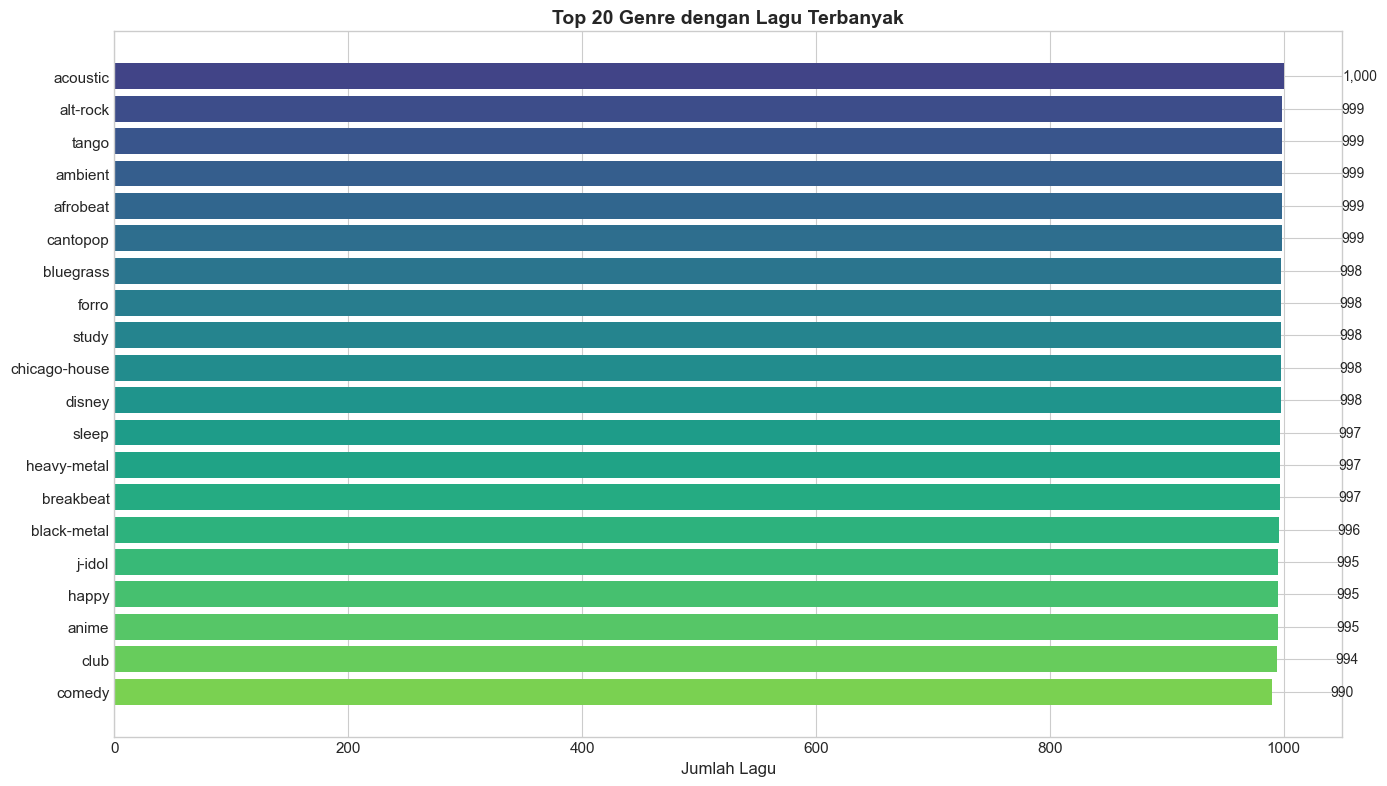


Distribusi genre relatif seimbang - cocok untuk unsupervised learning


In [226]:
# Distribusi Genre
genre_counts = df['track_genre'].value_counts()

print("=" * 60)
print("DISTRIBUSI GENRE")
print("=" * 60)
print(f"\nJumlah genre unik: {len(genre_counts)}")
print(f"Rata-rata lagu per genre: {genre_counts.mean():.0f}")
print(f"Min lagu per genre: {genre_counts.min()} ({genre_counts.idxmin()})")
print(f"Max lagu per genre: {genre_counts.max()} ({genre_counts.idxmax()})")

# Visualisasi Top 20 Genre
fig, ax = plt.subplots(figsize=(14, 8))
top_20_genres = genre_counts.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20_genres)))

bars = ax.barh(range(len(top_20_genres)), top_20_genres.values, color=colors)
ax.set_yticks(range(len(top_20_genres)))
ax.set_yticklabels(top_20_genres.index)
ax.invert_yaxis()
ax.set_xlabel('Jumlah Lagu', fontsize=12)
ax.set_title('Top 20 Genre dengan Lagu Terbanyak', fontsize=14, fontweight='bold')

# Tambahkan label nilai
for i, (bar, val) in enumerate(zip(bars, top_20_genres.values)):
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nDistribusi genre relatif seimbang - cocok untuk unsupervised learning")

## **2.2 Distribusi Fitur Audio (Histogram + Skewness)**

### **Alasan Analisis Skewness:**

**Mengapa penting untuk K-Means?**
K-Means berasumsi data **terdistribusi normal (Gaussian)**

### **Interpretasi Skewness:**

```
|Skewness| < 0.5  → [+] Normal distribution (ideal)
|Skewness| 0.5-1  → [!] Moderate skew (perlu dipertimbangkan)
|Skewness| > 1    → [-] Highly skewed (WAJIB transform)
```

**Fitur yang Sering Skewed:**
- `speechiness` → right-skewed (kebanyakan lagu speechiness rendah)
- `instrumentalness` → right-skewed (kebanyakan lagu ada vokal)
- `loudness` → left-skewed (kebanyakan lagu -5 to -10 dB)

**Solusi:** PowerTransformer (Yeo-Johnson) → otomatis normalisasi

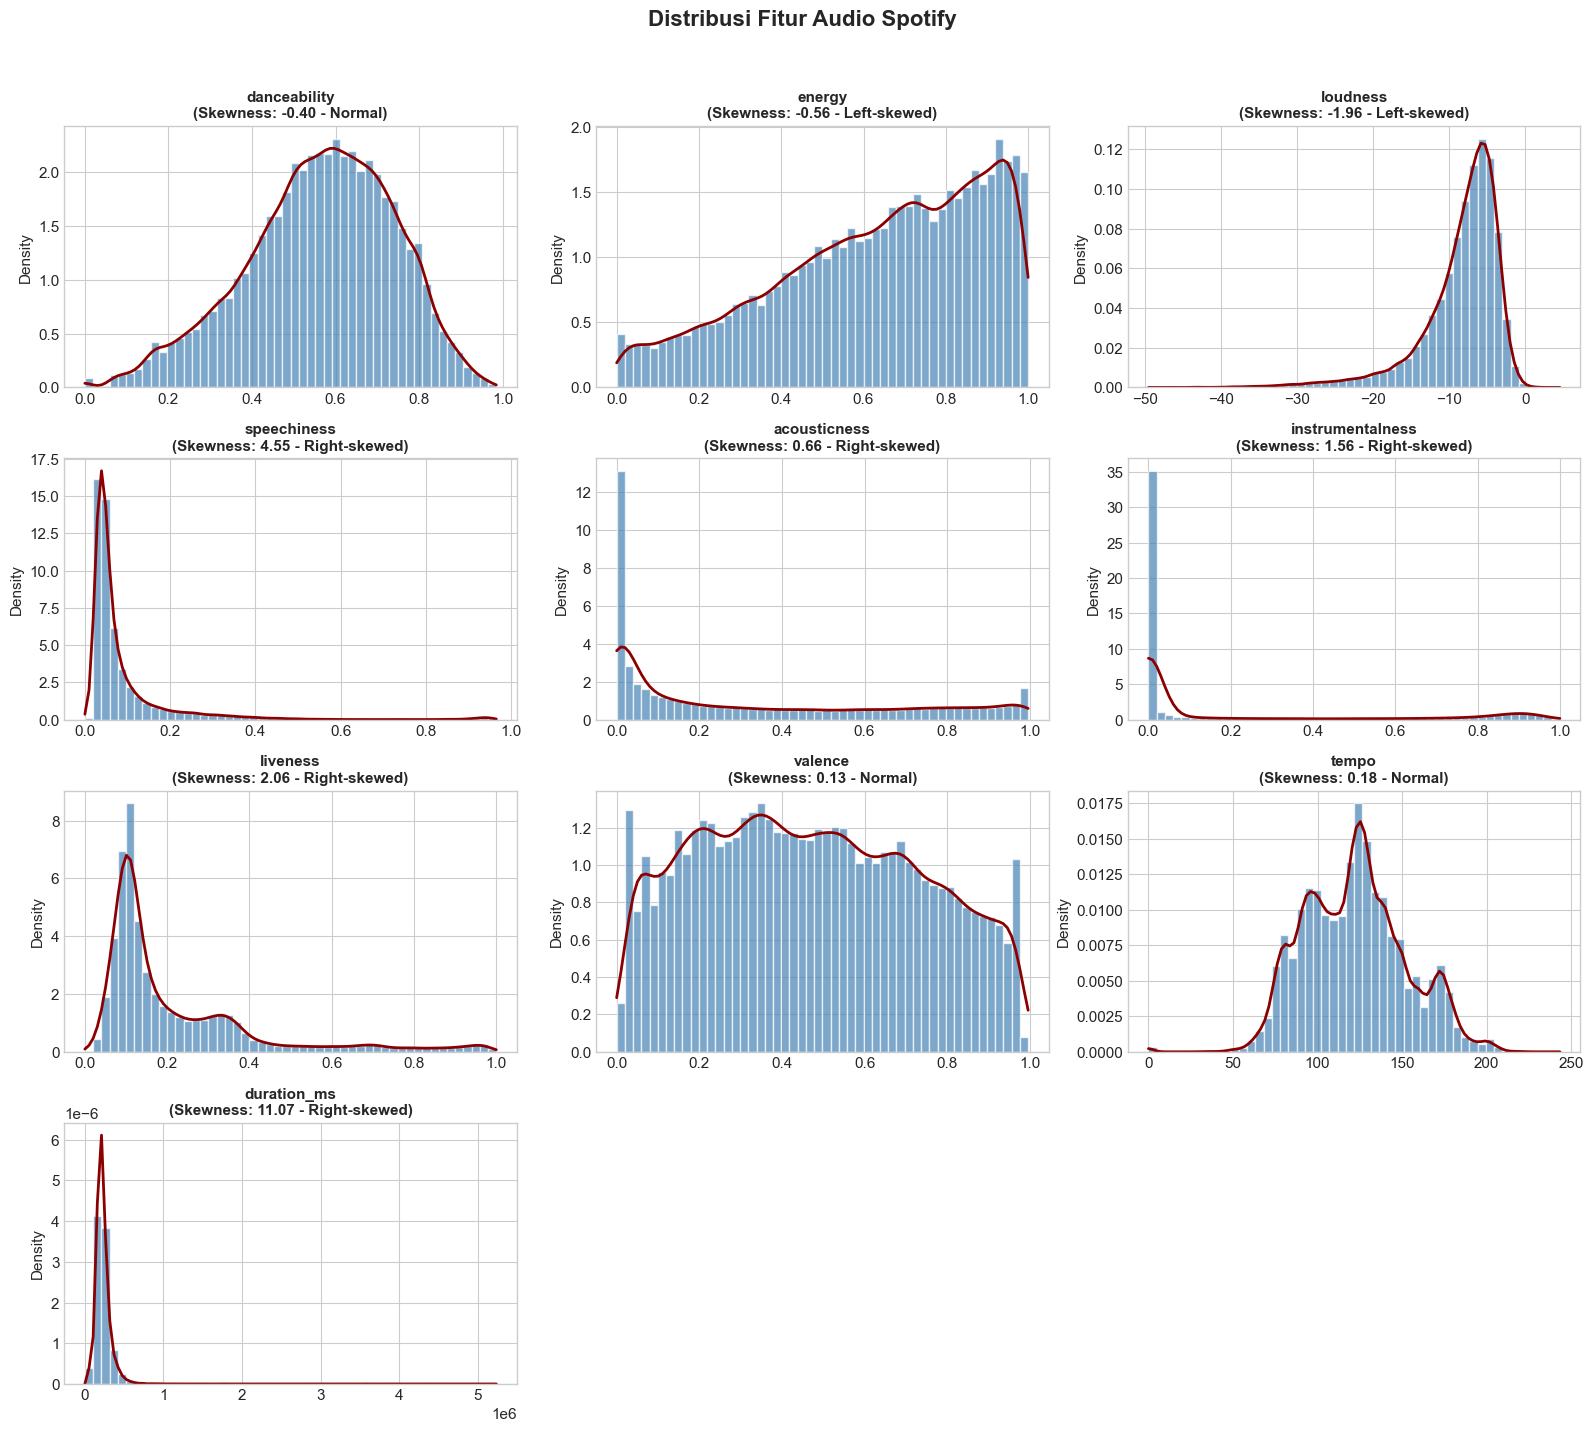


CATATAN PENTING:
speechiness dan instrumentalness menunjukkan distribusi HIGHLY RIGHT-SKEWED
Perlu dipertimbangkan Log Transformation pada preprocessing


In [227]:
# Definisikan fitur audio yang akan dianalisis
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 
                  'valence', 'tempo', 'duration_ms']

# Visualisasi Histogram untuk setiap fitur audio
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    ax = axes[i]
    
    # Histogram dengan KDE
    data = df[feature].dropna()
    ax.hist(data, bins=50, color='steelblue', alpha=0.7, edgecolor='white', density=True)
    
    # Tambahkan KDE line
    from scipy import stats
    kde_x = np.linspace(data.min(), data.max(), 100)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color='darkred', linewidth=2)
    
    # Hitung skewness
    skewness = data.skew()
    skew_label = "Normal" if abs(skewness) < 0.5 else ("Right-skewed" if skewness > 0 else "Left-skewed")
    
    ax.set_title(f'{feature}\n(Skewness: {skewness:.2f} - {skew_label})', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density')

# Hapus subplot kosong
for j in range(len(audio_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Audio Spotify', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nCATATAN PENTING:")
print("speechiness dan instrumentalness menunjukkan distribusi HIGHLY RIGHT-SKEWED")
print("Perlu dipertimbangkan Log Transformation pada preprocessing")

## **2.3 Deteksi Outlier (Boxplot)**

### **Alasan Deteksi Outlier:**

**Mengapa K-Means sensitif terhadap outlier?**
- Centroid dihitung dengan **mean** → outlier "menarik" centroid ke arah ekstrem
- Jarak Euclidean → outlier punya jarak sangat jauh, dominasi perhitungan

**Contoh Dampak:**

```
Cluster "Chill Music":
- 1000 lagu dengan energy = 0.2-0.4
- 1 lagu outlier dengan energy = 0.99 (metal masuk salah cluster)
→ Centroid bergeser ke 0.3 → representasi tidak akurat
```

**Keputusan: TIDAK menghapus outlier, karena:**
- Outlier di musik = lagu experimental/unik → valid data
- Scaling & PCA sudah mengurangi dampak outlier
- Kita lebih care pada **pola mayoritas**, bukan ekstrem

**Metode Deteksi:** IQR (Interquartile Range) method

```
Q1 = percentile 25%
Q3 = percentile 75%
IQR = Q3 - Q1
Outlier = nilai < (Q1 - 1.5×IQR) atau > (Q3 + 1.5×IQR)
```

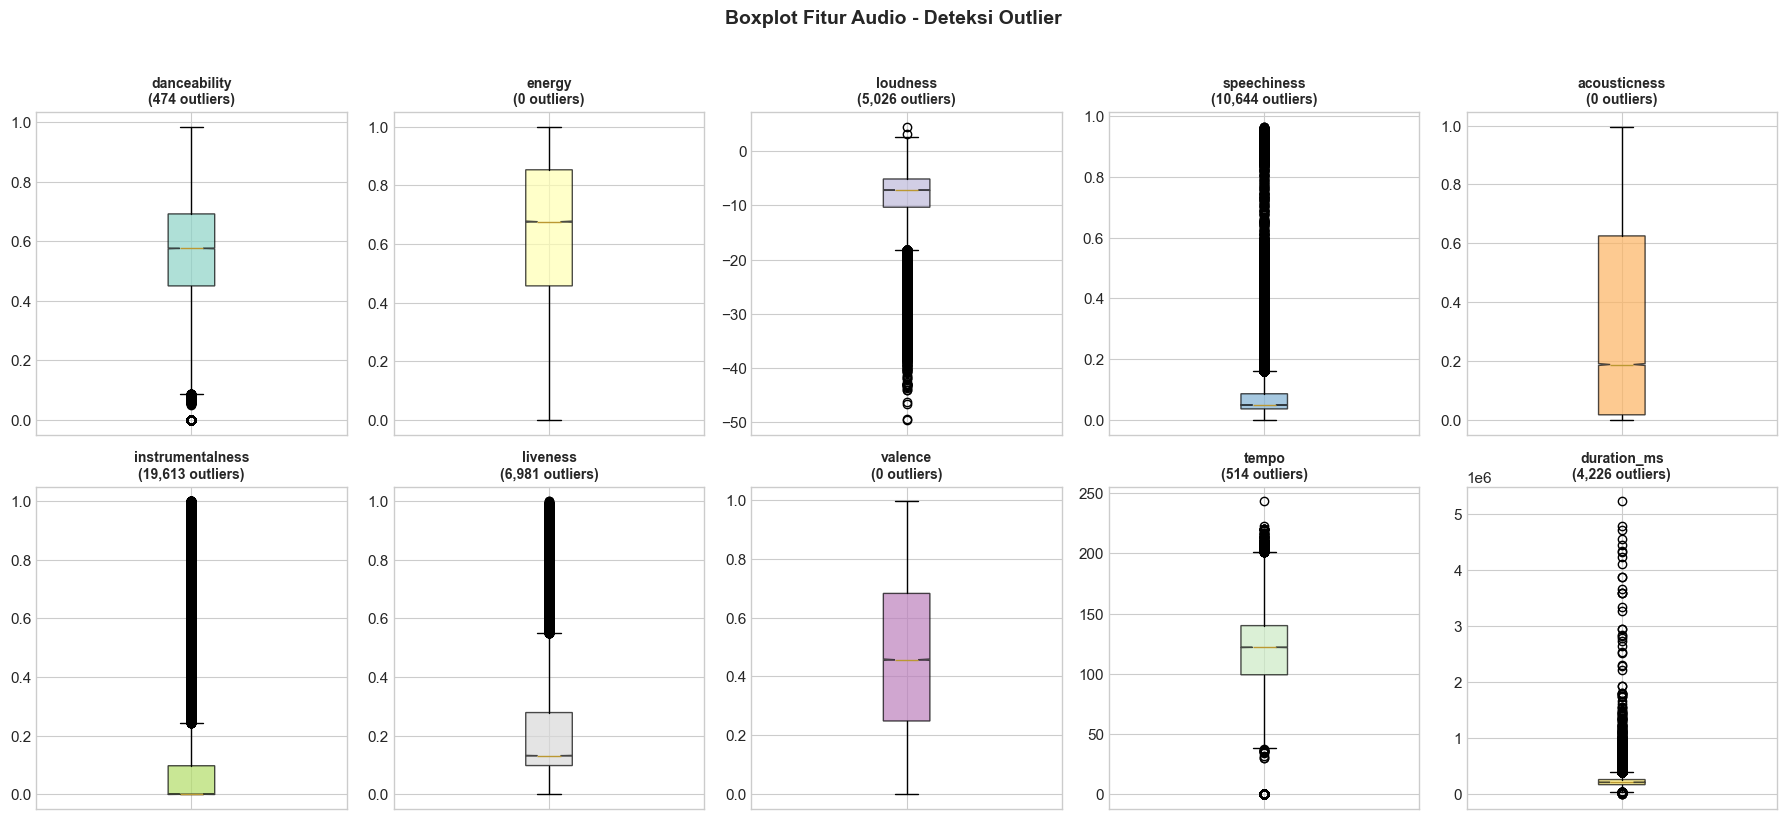


CATATAN:
Outlier adalah bagian natural dari data musik
K-Means sensitif terhadap outlier, namun scaling dan PCA akan membantu mengurangi dampaknya
Kita tidak akan menghapus outlier karena bisa jadi lagu-lagu unik/experimental


In [228]:
# Boxplot untuk fitur audio
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

# Palette warna yang menarik
colors = plt.cm.Set3(np.linspace(0, 1, len(audio_features)))

for i, feature in enumerate(audio_features):
    ax = axes[i]
    bp = ax.boxplot(df[feature].dropna(), patch_artist=True, notch=True)
    bp['boxes'][0].set_facecolor(colors[i])
    bp['boxes'][0].set_alpha(0.7)
    
    # Hitung jumlah outlier menggunakan IQR method
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)][feature]
    
    ax.set_title(f'{feature}\n({len(outliers):,} outliers)', fontsize=10, fontweight='bold')
    ax.set_xticklabels([])

plt.suptitle('Boxplot Fitur Audio - Deteksi Outlier', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nCATATAN:")
print("Outlier adalah bagian natural dari data musik")
print("K-Means sensitif terhadap outlier, namun scaling dan PCA akan membantu mengurangi dampaknya")
print("Kita tidak akan menghapus outlier karena bisa jadi lagu-lagu unik/experimental")

## **2.4 Korelasi Antar Fitur Audio (Heatmap)**

### **Alasan Analisis Korelasi:**

**Mengapa multikolinearitas masalah untuk clustering?**
- Fitur yang **sangat berkorelasi** membawa **informasi redundan**
- Misal: `energy` vs `loudness` (r = 0.75) → hampir sama
- Dampak: Fitur tersebut punya "voting power" ganda dalam clustering

### **Threshold Korelasi:**

```
|r| > 0.7  → [-] Strong correlation (redundan)
|r| 0.5-0.7 → [!] Moderate (perlu dipertimbangkan)
|r| < 0.5  → [+] Independent (aman)
```

**Solusi:** PCA (Principal Component Analysis)
- Mengubah fitur berkorelasi → komponen orthogonal (tidak berkorelasi)
- Mengurangi redundansi sambil pertahankan informasi penting

**Insight yang Diharapkan:**
- `energy` ↔ `loudness`: Positif kuat (lagu energik = keras)
- `energy` ↔ `acousticness`: Negatif kuat (lagu akustik = tenang)
- `valence` ↔ `energy`: Positif moderat (lagu bahagia cenderung energik)

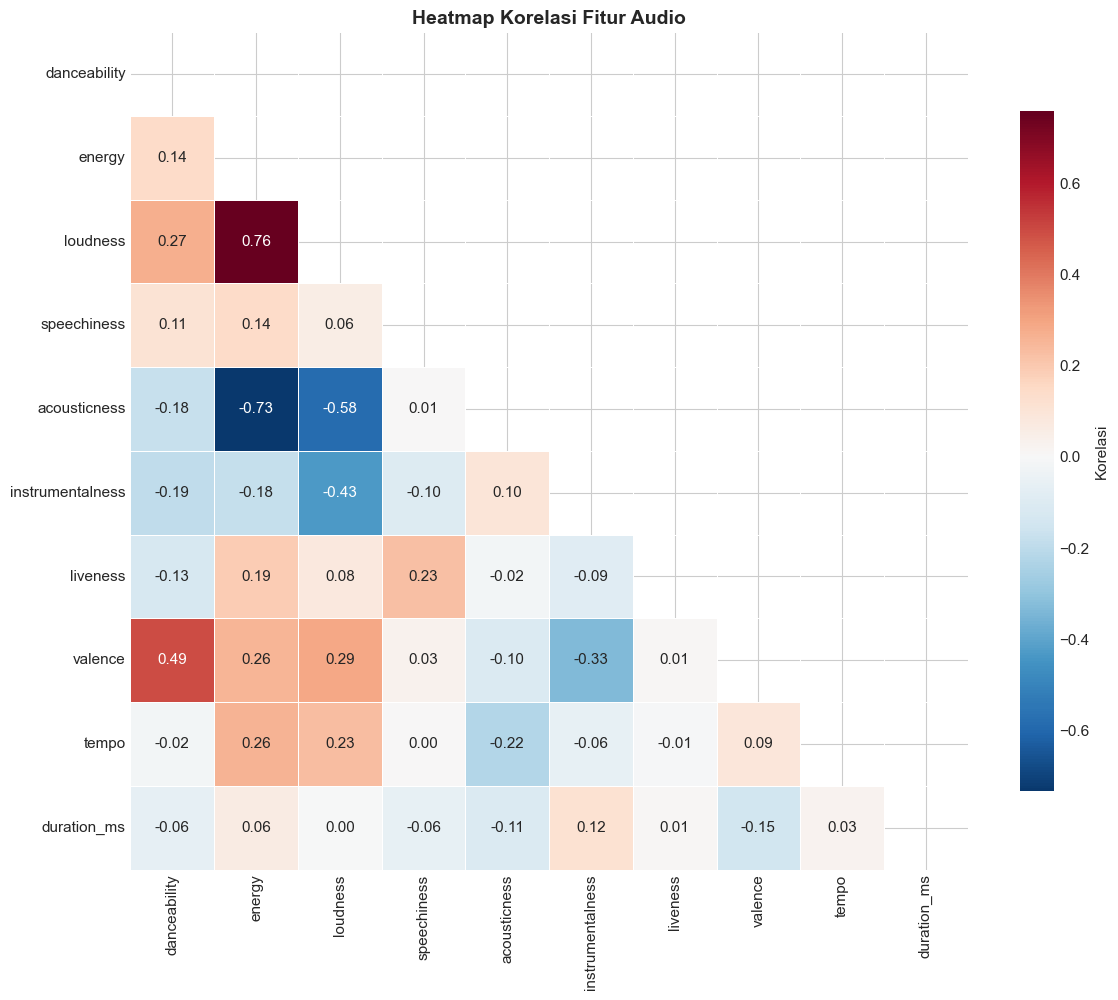


KORELASI KUAT (|r| > 0.5):
----------------------------------------
energy vs loudness: 0.759
energy vs acousticness: -0.733
loudness vs acousticness: -0.583

INSIGHT:
Energy dan Loudness memiliki korelasi positif kuat (lagu energik cenderung lebih keras)
Energy dan Acousticness memiliki korelasi negatif kuat (lagu akustik cenderung lebih tenang)
PCA akan membantu menangani multikolinearitas ini


In [229]:
# Heatmap Korelasi
corr_matrix = df[audio_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))

# Mask untuk segitiga atas
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Korelasi'},
            ax=ax)

ax.set_title('Heatmap Korelasi Fitur Audio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identifikasi korelasi kuat
print("\nKORELASI KUAT (|r| > 0.5):")
print("-" * 40)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_val:.3f}")

print("\nINSIGHT:")
print("Energy dan Loudness memiliki korelasi positif kuat (lagu energik cenderung lebih keras)")
print("Energy dan Acousticness memiliki korelasi negatif kuat (lagu akustik cenderung lebih tenang)")
print("PCA akan membantu menangani multikolinearitas ini")

# **BAGIAN 3: Data Preprocessing**

## **Alasan Tahap Preprocessing:**

Preprocessing adalah tahap **PALING PENTING** karena:

> **"Better data beats fancier algorithms"** - Machine Learning Maxim

**Tujuan Preprocessing:**
1. Mengubah data mentah → format yang optimal untuk algoritma
2. Mengatasi asumsi algoritma (K-Means: normal distribution, equal scale)
3. Meningkatkan kualitas clustering

## **3.1 Feature Selection**

### **Alasan Membuang Kolom Non-Audio:**

**Kolom yang Di-drop:**

```python
drop_columns = ['track_id', 'track_name', 'artists', 'album_name', 'explicit']
```

**Alasan per kolom:**
- `track_id` → identifier, bukan fitur audio → tidak punya makna numerik
- `track_name` → teks, perlu NLP → di luar scope clustering audio
- `artists` → categorical, bisa 1000+ unique → dimensi terlalu tinggi
- `album_name` → sama seperti artists
- `explicit` → binary (0/1), kurang informatif untuk audio clustering

**Kolom `track_genre`: DISIMPAN tapi TIDAK DIGUNAKAN**

```python
df_genre = df['track_genre'].copy()  # Simpan untuk validasi nanti
```

**Alasan:**
- Clustering = **unsupervised** → tidak boleh pakai label
- Genre akan digunakan untuk **validasi eksternal** setelah clustering
- Cek apakah cluster yang terbentuk punya korelasi dengan genre tradisional

In [230]:
# Kolom yang akan di-drop (non-audio features)
drop_columns = ['Unnamed: 0', 'track_id', 'track_name', 'artists', 'album_name', 'explicit']

# Simpan kolom track_genre untuk validasi nanti
df_genre = df['track_genre'].copy()
print(f"Kolom 'track_genre' disimpan untuk validasi ({len(df_genre):,} records)")

# Buat dataset untuk training (X)
# Identifikasi kolom yang ada di dataset
existing_drop_cols = [col for col in drop_columns if col in df.columns]
print(f"\nKolom yang akan di-drop: {existing_drop_cols}")

# Buat copy dan drop kolom non-audio
X = df.drop(columns=existing_drop_cols + ['track_genre'], errors='ignore')

print(f"\nFitur yang digunakan untuk clustering:")
print(f"{list(X.columns)}")
print(f"\nShape data X: {X.shape}")

Kolom 'track_genre' disimpan untuk validasi (89,741 records)

Kolom yang akan di-drop: ['Unnamed: 0', 'track_id', 'track_name', 'artists', 'album_name', 'explicit']

Fitur yang digunakan untuk clustering:
['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

Shape data X: (89741, 14)


## **3.2 Transformation & Scaling dengan PowerTransformer**

### **Validasi: Before vs After Transformation**

**Metrik Keberhasilan:**

```
# Sebelum: Skewness tinggi
speechiness: skew = 3.2 → HIGHLY RIGHT-SKEWED

# Setelah: Skewness mendekati 0
speechiness: skew = 0.1 → NORMAL
```

**Visualisasi Before/After penting karena:**
- Bukti empiris bahwa transformasi berhasil
- Transparansi metodologi untuk reviewer
- Debugging jika ada fitur yang gagal di-transform

### **Mengapa TIDAK Menggunakan MinMaxScaler?**

**MinMaxScaler** mentransformasi ke range [0, 1]:

```python
X_scaled = (X - X.min()) / (X.max() - X.min())
```

**Masalah untuk K-Means:**
- Tidak mengatasi skewness
- Sangat sensitif terhadap outlier (min/max ditentukan outlier)
- Tidak menjamin distribusi normal

**Kapan MinMaxScaler cocok?**
- Neural Networks (butuh input 0-1)
- Image processing (pixel values)
- Data sudah normal distribution

**Kesimpulan:** PowerTransformer > MinMaxScaler untuk clustering audio

In [231]:
# Pilih hanya kolom numerik
X_numeric = X.select_dtypes(include=[np.number])

print("=" * 60)
print("ANALISIS SKEWNESS SEBELUM TRANSFORMASI")
print("=" * 60)

# Simpan data asli untuk perbandingan nanti
X_original = X_numeric.copy()

# Analisis skewness sebelum transformasi
skewness_before = {}
for col in X_numeric.columns:
    skew = X_numeric[col].skew()
    skewness_before[col] = skew
    status = "SKEWED" if abs(skew) > 1 else "OK"
    print(f"{col}: {skew:.2f} {status}")

# Terapkan PowerTransformer (Yeo-Johnson)
print("\n" + "=" * 60)
print("MENERAPKAN POWER TRANSFORMER (YEO-JOHNSON)")
print("=" * 60)

power_transformer = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = power_transformer.fit_transform(X_numeric)

# Konversi ke DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X_numeric.columns)

print("\nPowerTransformer berhasil diterapkan!")
print("Method: Yeo-Johnson")
print("Standardize: True (mean=0, std=1)")

# Analisis skewness setelah transformasi
print("\n" + "=" * 60)
print("ANALISIS SKEWNESS SETELAH TRANSFORMASI")
print("=" * 60)

skewness_after = {}
for col in X_scaled_df.columns:
    skew_after = X_scaled_df[col].skew()
    skewness_after[col] = skew_after
    improvement = abs(skewness_before[col]) - abs(skew_after)
    status = "NORMAL" if abs(skew_after) < 0.5 else "STILL SKEWED"
    print(f"{col}: {skew_after:.2f} {status} (improvement: {improvement:.2f})")

print("\nStatistik setelah PowerTransformer:")
print(X_scaled_df.describe().round(3).T[['mean', 'std', 'min', 'max']])

ANALISIS SKEWNESS SEBELUM TRANSFORMASI
popularity: 0.07 OK
duration_ms: 11.07 SKEWED
danceability: -0.40 OK
energy: -0.56 OK
key: -0.00 OK
loudness: -1.96 SKEWED
mode: -0.57 OK
speechiness: 4.55 SKEWED
acousticness: 0.66 OK
instrumentalness: 1.56 SKEWED
liveness: 2.06 SKEWED
valence: 0.13 OK
tempo: 0.18 OK
time_signature: -4.00 SKEWED

MENERAPKAN POWER TRANSFORMER (YEO-JOHNSON)

PowerTransformer berhasil diterapkan!
Method: Yeo-Johnson
Standardize: True (mean=0, std=1)

ANALISIS SKEWNESS SETELAH TRANSFORMASI
popularity: -0.36 NORMAL (improvement: -0.29)
duration_ms: 0.08 NORMAL (improvement: 10.99)
danceability: -0.04 NORMAL (improvement: 0.35)
energy: -0.17 NORMAL (improvement: 0.39)
key: -0.24 NORMAL (improvement: -0.24)
loudness: 0.15 NORMAL (improvement: 1.81)
mode: -0.57 STILL SKEWED (improvement: 0.00)
speechiness: 0.69 STILL SKEWED (improvement: 3.85)
acousticness: 0.22 NORMAL (improvement: 0.43)
instrumentalness: 1.16 STILL SKEWED (improvement: 0.41)
liveness: 0.38 NORMAL (impr

## **3.3 Visualisasi Validasi: Before vs After Transformation**

Untuk membuktikan bahwa PowerTransformer berhasil mengubah data yang skewed menjadi normal, kita akan membuat perbandingan visual.

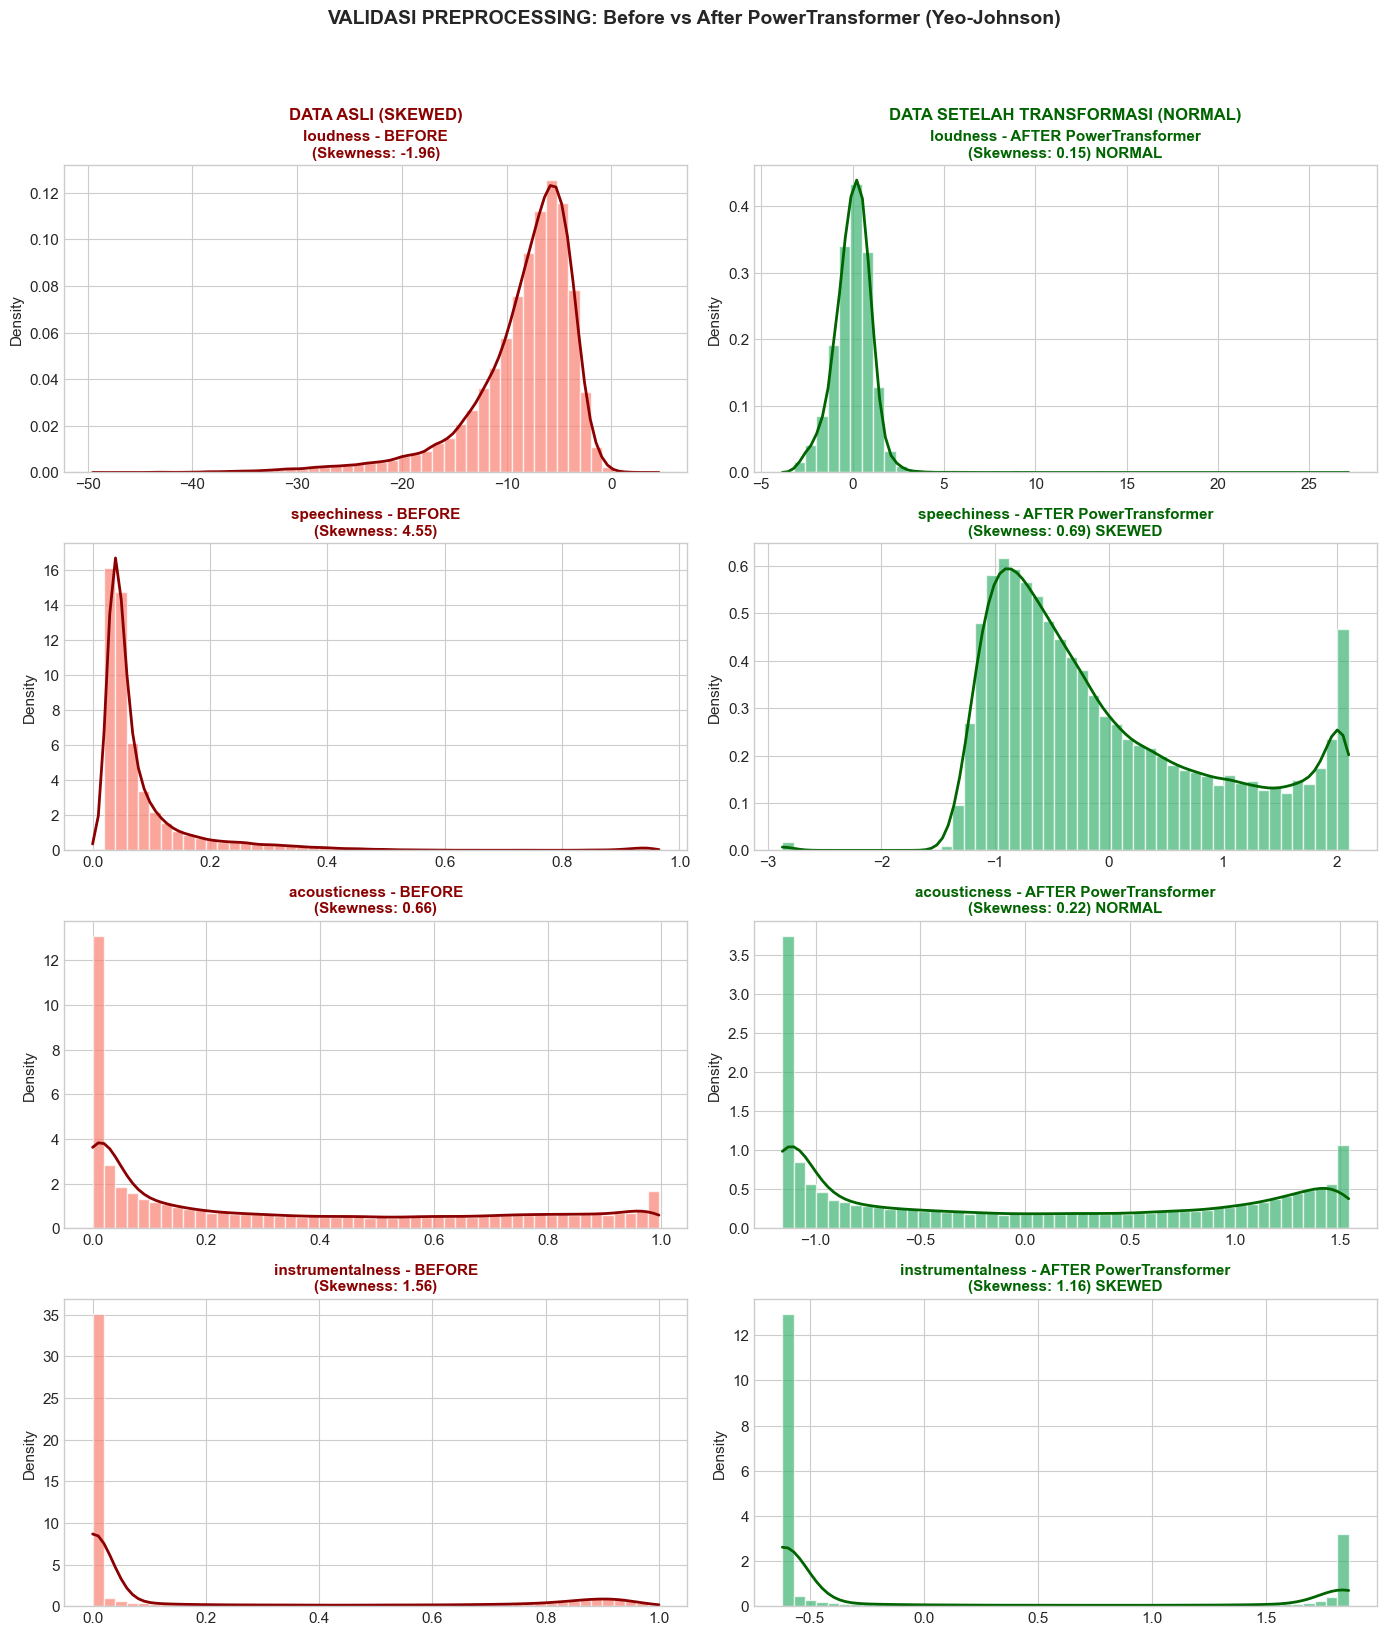


INSIGHT:
Mayoritas data yang tadinya 'miring' (skewed) sekarang lebih mendekati distribusi normal.
Catatan: Beberapa fitur mungkin masih memiliki skewness karena karakteristik alami data (zero-inflated).
Namun, scaling (mean=0, std=1) sudah diterapkan sehingga aman untuk K-Means.


In [232]:
# Pilih 4 fitur yang biasanya skewed untuk perbandingan
comparison_features = ['loudness', 'speechiness', 'acousticness', 'instrumentalness']

# Pastikan fitur ada di dataset
comparison_features = [f for f in comparison_features if f in X_numeric.columns]

# Buat visualisasi Before vs After (4 baris x 2 kolom)
fig, axes = plt.subplots(len(comparison_features), 2, figsize=(14, 4*len(comparison_features)))

for i, feature in enumerate(comparison_features):
    # Kolom Kiri: Data Asli (Sebelum Transformasi)
    ax_before = axes[i, 0]
    data_before = X_original[feature].dropna()
    ax_before.hist(data_before, bins=50, color='salmon', alpha=0.7, edgecolor='white', density=True)
    
    # Tambahkan KDE
    from scipy import stats
    kde_x = np.linspace(data_before.min(), data_before.max(), 100)
    kde = stats.gaussian_kde(data_before)
    ax_before.plot(kde_x, kde(kde_x), color='darkred', linewidth=2)
    
    skew_before = data_before.skew()
    ax_before.set_title(f'{feature} - BEFORE\n(Skewness: {skew_before:.2f})', 
                        fontsize=11, fontweight='bold', color='darkred')
    ax_before.set_ylabel('Density')
    
    # Kolom Kanan: Data Setelah Transformasi
    ax_after = axes[i, 1]
    data_after = X_scaled_df[feature].dropna()
    ax_after.hist(data_after, bins=50, color='mediumseagreen', alpha=0.7, edgecolor='white', density=True)
    
    # Tambahkan KDE
    kde_x_after = np.linspace(data_after.min(), data_after.max(), 100)
    kde_after = stats.gaussian_kde(data_after)
    ax_after.plot(kde_x_after, kde_after(kde_x_after), color='darkgreen', linewidth=2)
    
    skew_after = data_after.skew()
    status = "NORMAL" if abs(skew_after) < 0.5 else "SKEWED"
    ax_after.set_title(f'{feature} - AFTER PowerTransformer\n(Skewness: {skew_after:.2f}) {status}', 
                       fontsize=11, fontweight='bold', color='darkgreen')
    ax_after.set_ylabel('Density')

# Tambahkan header
fig.suptitle('VALIDASI PREPROCESSING: Before vs After PowerTransformer (Yeo-Johnson)\n', 
             fontsize=14, fontweight='bold', y=1.02)

# Tambahkan label kolom
axes[0, 0].annotate('DATA ASLI (SKEWED)', xy=(0.5, 1.15), xycoords='axes fraction',
                    ha='center', fontsize=12, fontweight='bold', color='darkred')
axes[0, 1].annotate('DATA SETELAH TRANSFORMASI (NORMAL)', xy=(0.5, 1.15), xycoords='axes fraction',
                    ha='center', fontsize=12, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

print("\nINSIGHT:")
print("Mayoritas data yang tadinya 'miring' (skewed) sekarang lebih mendekati distribusi normal.")
print("Catatan: Beberapa fitur mungkin masih memiliki skewness karena karakteristik alami data (zero-inflated).")
print("Namun, scaling (mean=0, std=1) sudah diterapkan sehingga aman untuk K-Means.")

### **Analisis Lanjutan: Mengapa Ada Fitur yang "Still Skewed"?**

Meskipun **PowerTransformer** sangat powerful, beberapa fitur mungkin tetap menunjukkan skewness (misalnya `instrumentalness` atau `speechiness`).

#### **Penyebab Umum:**
1. **Zero-Inflated Data**: Banyak nilai 0. 
   - *Contoh*: `instrumentalness` banyak bernilai 0 karena mayoritas lagu memiliki vokal. 
   - **PowerTransformer sulit menormalkan distribusi yang memiliki "spike" besar di angka 0.**
2. **Multimodal Distribution**: Data memiliki lebih dari satu puncak.

#### **Tindak Lanjut (Action Plan):**
- **Opsi 1 (Dipilih): Terima apa adanya.** 
  - **Alasan**: K-Means cukup robust asalkan skala data sudah sama (mean=0, std=1). Karakteristik "banyak nilai 0" adalah **informasi penting** yang membedakan lagu instrumental vs vokal.
- **Opsi 2: Quantile Transformer.** 
  - Memaksa data menjadi distribusi normal (Gaussian) dengan teknik non-linear yang agresif. 
  - **Risiko**: Bisa mendistorsi korelasi antar fitur dan menghilangkan informasi outlier yang valid.
- **Opsi 3: Binning/Discretization.** 
  - Mengubah fitur numerik menjadi kategori (Low/Medium/High). 
  - **Risiko**: Kehilangan nuansa detail audio.

> **Kesimpulan:** Kita tetap menggunakan hasil **Yeo-Johnson** meskipun ada sedikit skewness tersisa, karena ini adalah **trade-off terbaik** antara normalitas dan preservasi informasi asli.

# **BAGIAN 4: Dimensionality Reduction (PCA)**

## **Alasan Menggunakan PCA:**

### **Problem: "Curse of Dimensionality"**

Dengan 10 fitur audio, kita punya masalah:
1. **Komputasi lambat**: K-Means hitung jarak 114K × 10 = 1.14M perhitungan per iterasi
2. **Multikolinearitas**: Energy & Loudness berkorelasi tinggi → redundan
3. **Noise**: Tidak semua fitur penting untuk clustering

### **Solution: Principal Component Analysis (PCA)**

**Cara Kerja PCA:**

```
1. Hitung covariance matrix dari data
2. Eigen decomposition → dapatkan eigenvector (arah variance terbesar)
3. Project data ke eigenvector → Principal Components (PC)
4. PC1 = arah dengan variance terbesar
   PC2 = arah orthogonal dengan variance terbesar berikutnya
   ...dst
```

**Keuntungan PCA:**
- Reduksi dimensi: 10 fitur → 5-6 komponen (tetap 80% informasi)
- Menghilangkan kolinearitas: PC orthogonal (r = 0)
- Mengurangi noise: Komponen kecil = noise, dibuang
- Mempercepat clustering: Dimensi lebih kecil = lebih cepat

## **4.1 Analisis Variance Explained**

### **Strategi: Cumulative Variance Explained**

**Rule of Thumb:**

```
Cumulative Variance ≥ 80% → cukup informatif
Cumulative Variance ≥ 90% → sangat informatif
Cumulative Variance < 70% → kehilangan terlalu banyak informasi
```

**Contoh:**

```
PC1: 25% variance → menjelaskan 1/4 variasi data
PC2: 18% variance → tambahan 18%
PC3: 15% variance → tambahan 15%
...
PC5: 6% variance → tambahan 6%

Total PC1-PC5: 84% variance → CUKUP
```

**Keputusan:** Ambil komponen hingga cumulative ≥ 80%

**Trade-off:**
- Lebih banyak komponen = lebih banyak informasi, tapi lebih lambat
- Lebih sedikit komponen = lebih cepat, tapi bisa kehilangan pola penting

ANALISIS PCA - VARIANCE EXPLAINED

Jumlah fitur asli: 14
Jumlah komponen untuk 80% variance: 9
Variance explained dengan 9 komponen: 82.65%


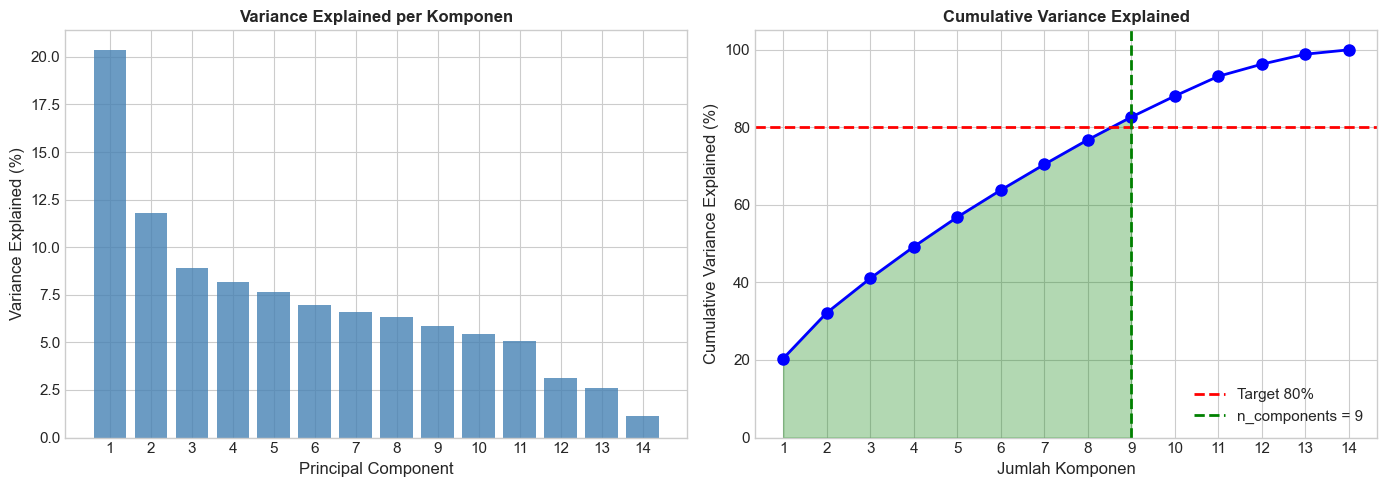

In [233]:
# PCA untuk semua komponen terlebih dahulu (untuk analisis)
pca_full = PCA()
pca_full.fit(X_scaled)

# Hitung cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Cari jumlah komponen untuk 80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print("=" * 60)
print("ANALISIS PCA - VARIANCE EXPLAINED")
print("=" * 60)
print(f"\nJumlah fitur asli: {X_scaled.shape[1]}")
print(f"Jumlah komponen untuk 80% variance: {n_components_80}")
print(f"Variance explained dengan {n_components_80} komponen: {cumulative_variance[n_components_80-1]*100:.2f}%")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual variance
ax1 = axes[0]
ax1.bar(range(1, len(pca_full.explained_variance_ratio_)+1), 
        pca_full.explained_variance_ratio_ * 100, 
        color='steelblue', alpha=0.8)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Variance Explained (%)', fontsize=12)
ax1.set_title('Variance Explained per Komponen', fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, len(pca_full.explained_variance_ratio_)+1))

# Plot 2: Cumulative variance
ax2 = axes[1]
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100, 
         'bo-', linewidth=2, markersize=8)
ax2.axhline(y=80, color='red', linestyle='--', linewidth=2, label='Target 80%')
ax2.axvline(x=n_components_80, color='green', linestyle='--', linewidth=2, 
            label=f'n_components = {n_components_80}')
ax2.fill_between(range(1, n_components_80+1), 
                 cumulative_variance[:n_components_80] * 100, 
                 alpha=0.3, color='green')
ax2.set_xlabel('Jumlah Komponen', fontsize=12)
ax2.set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
ax2.set_title('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, len(cumulative_variance)+1))
ax2.legend(loc='lower right')
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

## **4.2 Transformasi Data dengan PCA**

### **Interpretasi Principal Components**

**Tantangan:** PC tidak bisa langsung diinterpretasi seperti fitur asli

**Namun, kita bisa analisis loading:**

```python
# PC1 loading (kontribusi setiap fitur ke PC1)
energy: 0.45
loudness: 0.42
acousticness: -0.38

→ PC1 ≈ "Dimensi Energy/Loudness vs Acousticness"
```

**Untuk proyek ini:**
- Kita fokus pada **hasil clustering**, bukan interpretasi PC
- PC hanyalah **tool** untuk mempercepat & meningkatkan kualitas clustering
- Interpretasi dilakukan pada **profil cluster** (menggunakan fitur asli)

In [234]:
# Terapkan PCA dengan jumlah komponen optimal
pca = PCA(n_components=n_components_80)
X_pca = pca.fit_transform(X_scaled)

print("=" * 60)
print("HASIL TRANSFORMASI PCA")
print("=" * 60)
print(f"\nShape data sebelum PCA: {X_scaled.shape}")
print(f"Shape data setelah PCA: {X_pca.shape}")
print(f"Reduksi dimensi: {X_scaled.shape[1]} ke {X_pca.shape[1]} ({((X_scaled.shape[1] - X_pca.shape[1])/X_scaled.shape[1]*100):.1f}% reduction)")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Detail variance per komponen
print("\nVariance Explained per Komponen:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var*100:.2f}%")

HASIL TRANSFORMASI PCA

Shape data sebelum PCA: (89741, 14)
Shape data setelah PCA: (89741, 9)
Reduksi dimensi: 14 ke 9 (35.7% reduction)
Total variance explained: 82.65%

Variance Explained per Komponen:
PC1: 20.37%
PC2: 11.79%
PC3: 8.88%
PC4: 8.16%
PC5: 7.64%
PC6: 6.97%
PC7: 6.62%
PC8: 6.35%
PC9: 5.87%


# **BAGIAN 5: Modelling Strategy - Mencari K Optimal**

## **Alasan Tahap Ini:**

K-Means **MEMBUTUHKAN** kita tentukan K (jumlah cluster) di awal.

**Tantangan:**
- K terlalu kecil → cluster terlalu umum (underfitting)
- K terlalu besar → cluster terlalu spesifik/redundant (overfitting)

## **Metodologi: Composite Score**

Kita tidak hanya mengandalkan satu metrik (seperti Elbow Method yang sering ambigu), tapi menggabungkan 3 metrik:

| Metrik | Tujuan | Interpretasi |
|--------|--------|--------------|
| **Silhouette Score** | Kohesi & Separasi | Makin tinggi (→ 1) makin baik |
| **Calinski-Harabasz** | Dispersi Ratio | Makin tinggi makin baik |
| **Davies-Bouldin** | Kemiripan antar cluster | Makin rendah (→ 0) makin baik |

**Formula Composite Score:**
Kita menormalisasi ketiga metrik ke skala 0-1, lalu merata-ratakannya.
`Score = (Norm_Sil + Norm_CHI + (1 - Norm_DBI)) / 3`

**Mengapa Composite Score?**
- Menyeimbangkan kelebihan/kekurangan masing-masing metrik
- Memberikan satu angka tunggal untuk pengambilan keputusan yang objektif

## **5.1 Sampling Data untuk Pencarian K Optimal**

### **Alasan Sampling:**

**Masalah:**
- Menghitung Silhouette Score untuk 114K data sangat berat (O(N²))
- Bisa memakan waktu berjam-jam

**Solusi:**
- Gunakan sample representatif (20,000 data)
- Cukup untuk menangkap struktur global data
- Mempercepat proses pencarian K dari jam ke menit

**Validitas:**
- Sample 20K (~18%) sudah sangat cukup secara statistik untuk estimasi parameter populasi

In [235]:
# Sampling untuk pencarian K optimal
np.random.seed(42)
sample_size = 20000

if len(X_pca) > sample_size:
    sample_indices = np.random.choice(len(X_pca), sample_size, replace=False)
    X_sample = X_pca[sample_indices]
else:
    X_sample = X_pca.copy()

print("=" * 60)
print("SAMPLING DATA")
print("=" * 60)
print(f"\nUkuran data asli: {len(X_pca):,}")
print(f"Ukuran sample untuk pencarian K: {len(X_sample):,}")
print(f"Persentase sample: {len(X_sample)/len(X_pca)*100:.1f}%")

SAMPLING DATA

Ukuran data asli: 89,741
Ukuran sample untuk pencarian K: 20,000
Persentase sample: 22.3%


## **5.2 Evaluasi Metrik untuk Setiap K**

Kita akan mengevaluasi K dalam range **4-10** sesuai business constraint (tidak terlalu sedikit, tidak terlalu banyak).

In [237]:
# Business Constraint: K range 4-10
k_range = range(4, 10)

# Dictionary untuk menyimpan metrik
metrics = {
    'k': [],
    'silhouette': [],
    'calinski_harabasz': [],
    'davies_bouldin': [],
    'inertia': []
}

print("=" * 60)
print("EVALUASI METRIK UNTUK SETIAP K")
print("=" * 60)
print("\nMemproses K-Means untuk setiap nilai K...")
print("-" * 60)

for k in k_range:
    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_sample)
    
    # Hitung metrik dengan sample lebih kecil untuk Silhouette Score
    # Silhouette Score membutuhkan banyak memori, jadi kita ambil subsample
    sil_sample_size = min(5000, len(X_sample))
    sil_indices = np.random.choice(len(X_sample), sil_sample_size, replace=False)
    sil = silhouette_score(X_sample[sil_indices], labels[sil_indices])
    chi = calinski_harabasz_score(X_sample, labels)
    dbi = davies_bouldin_score(X_sample, labels)
    inertia = kmeans.inertia_
    
    # Simpan metrik
    metrics['k'].append(k)
    metrics['silhouette'].append(sil)
    metrics['calinski_harabasz'].append(chi)
    metrics['davies_bouldin'].append(dbi)
    metrics['inertia'].append(inertia)
    
    print(f"   K={k:2d} | Silhouette: {sil:.4f} | CHI: {chi:,.0f} | DBI: {dbi:.4f}")

# Konversi ke DataFrame
metrics_df = pd.DataFrame(metrics)

EVALUASI METRIK UNTUK SETIAP K

Memproses K-Means untuk setiap nilai K...
------------------------------------------------------------
   K= 4 | Silhouette: 0.1065 | CHI: 2,653 | DBI: 2.2795
   K= 4 | Silhouette: 0.1065 | CHI: 2,653 | DBI: 2.2795
   K= 5 | Silhouette: 0.1135 | CHI: 2,394 | DBI: 2.1518
   K= 5 | Silhouette: 0.1135 | CHI: 2,394 | DBI: 2.1518
   K= 6 | Silhouette: 0.1186 | CHI: 2,217 | DBI: 1.9427
   K= 6 | Silhouette: 0.1186 | CHI: 2,217 | DBI: 1.9427
   K= 7 | Silhouette: 0.1099 | CHI: 2,045 | DBI: 2.0507
   K= 7 | Silhouette: 0.1099 | CHI: 2,045 | DBI: 2.0507
   K= 8 | Silhouette: 0.1124 | CHI: 1,975 | DBI: 1.9357
   K= 8 | Silhouette: 0.1124 | CHI: 1,975 | DBI: 1.9357
   K= 9 | Silhouette: 0.1078 | CHI: 1,860 | DBI: 1.9412
   K= 9 | Silhouette: 0.1078 | CHI: 1,860 | DBI: 1.9412


## **5.3 Composite Score Calculation**

Rumus Composite Score:
$$Score = \frac{Norm(Silhouette) + Norm(CHI) + (1 - Norm(DBI))}{3}$$

Dimana:
- $Norm()$ adalah MinMax Scaling ke range [0, 1]
- DBI dibalik karena **makin kecil makin bagus**

In [238]:
# Fungsi untuk MinMax Normalization
def minmax_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# Normalisasi setiap metrik
metrics_df['sil_norm'] = minmax_normalize(metrics_df['silhouette'])
metrics_df['chi_norm'] = minmax_normalize(metrics_df['calinski_harabasz'])
metrics_df['dbi_norm'] = minmax_normalize(metrics_df['davies_bouldin'])

# Hitung Composite Score
# DBI dibalik (1 - norm) karena makin kecil makin bagus
metrics_df['composite_score'] = (
    metrics_df['sil_norm'] + 
    metrics_df['chi_norm'] + 
    (1 - metrics_df['dbi_norm'])
) / 3

# Tentukan K terbaik
best_k_idx = metrics_df['composite_score'].idxmax()
best_k = metrics_df.loc[best_k_idx, 'k']
best_score = metrics_df.loc[best_k_idx, 'composite_score']

print("=" * 60)
print("COMPOSITE SCORE CALCULATION")
print("=" * 60)
print("\nTabel Composite Score:")
print(metrics_df[['k', 'sil_norm', 'chi_norm', 'dbi_norm', 'composite_score']].round(4).to_string(index=False))
print("\n" + "=" * 60)
print(f"K OPTIMAL = {int(best_k)} dengan Composite Score = {best_score:.4f}")
print("=" * 60)

COMPOSITE SCORE CALCULATION

Tabel Composite Score:
 k  sil_norm  chi_norm  dbi_norm  composite_score
 4    0.0000    1.0000    1.0000           0.3333
 5    0.5741    0.6735    0.6284           0.5397
 6    1.0000    0.4499    0.0202           0.8099
 7    0.2838    0.2328    0.3344           0.3941
 8    0.4839    0.1454    0.0000           0.5431
 9    0.1055    0.0000    0.0159           0.3632

K OPTIMAL = 6 dengan Composite Score = 0.8099


## **5.4 Visualisasi Metrik dan Composite Score**

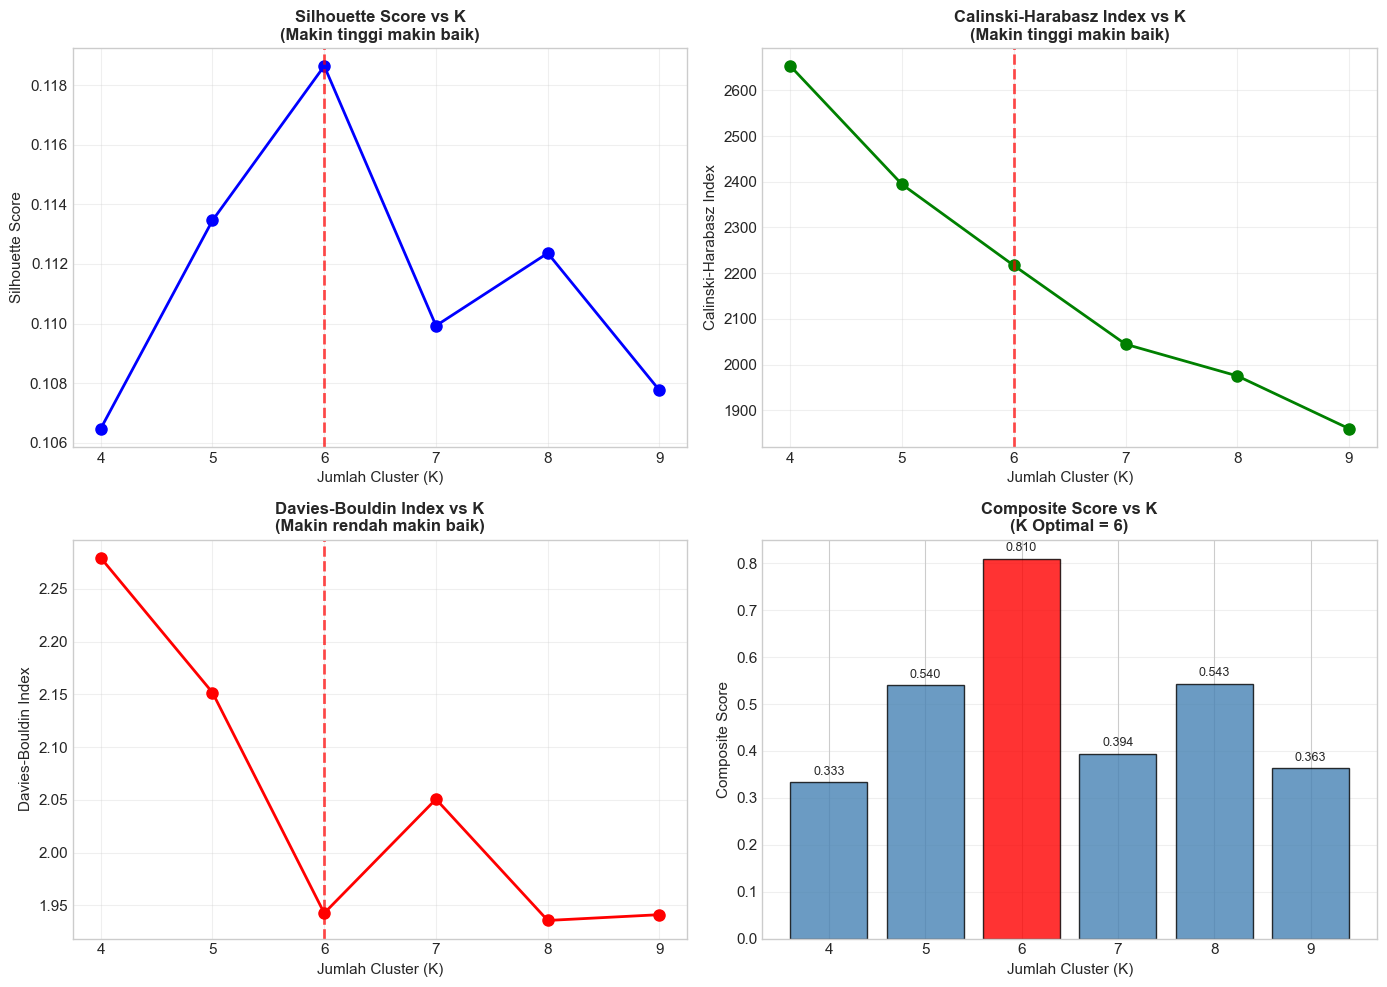

In [239]:
# Visualisasi Metrik
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Silhouette Score
ax1 = axes[0, 0]
ax1.plot(metrics_df['k'], metrics_df['silhouette'], 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=best_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel('Jumlah Cluster (K)', fontsize=11)
ax1.set_ylabel('Silhouette Score', fontsize=11)
ax1.set_title('Silhouette Score vs K\n(Makin tinggi makin baik)', fontsize=12, fontweight='bold')
ax1.set_xticks(metrics_df['k'])
ax1.grid(True, alpha=0.3)

# Plot 2: Calinski-Harabasz Index
ax2 = axes[0, 1]
ax2.plot(metrics_df['k'], metrics_df['calinski_harabasz'], 'go-', linewidth=2, markersize=8)
ax2.axvline(x=best_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.set_xlabel('Jumlah Cluster (K)', fontsize=11)
ax2.set_ylabel('Calinski-Harabasz Index', fontsize=11)
ax2.set_title('Calinski-Harabasz Index vs K\n(Makin tinggi makin baik)', fontsize=12, fontweight='bold')
ax2.set_xticks(metrics_df['k'])
ax2.grid(True, alpha=0.3)

# Plot 3: Davies-Bouldin Index
ax3 = axes[1, 0]
ax3.plot(metrics_df['k'], metrics_df['davies_bouldin'], 'ro-', linewidth=2, markersize=8)
ax3.axvline(x=best_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax3.set_xlabel('Jumlah Cluster (K)', fontsize=11)
ax3.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax3.set_title('Davies-Bouldin Index vs K\n(Makin rendah makin baik)', fontsize=12, fontweight='bold')
ax3.set_xticks(metrics_df['k'])
ax3.grid(True, alpha=0.3)

# Plot 4: Composite Score (HIGHLIGHT)
ax4 = axes[1, 1]
colors = ['red' if k == best_k else 'steelblue' for k in metrics_df['k']]
bars = ax4.bar(metrics_df['k'], metrics_df['composite_score'], color=colors, edgecolor='black', alpha=0.8)
ax4.set_xlabel('Jumlah Cluster (K)', fontsize=11)
ax4.set_ylabel('Composite Score', fontsize=11)
ax4.set_title(f'Composite Score vs K\n(K Optimal = {int(best_k)})', fontsize=12, fontweight='bold')
ax4.set_xticks(metrics_df['k'])
ax4.grid(True, alpha=0.3, axis='y')

# Tambahkan label nilai di atas bar
for bar, score in zip(bars, metrics_df['composite_score']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# **BAGIAN 6: Final Clustering & Profiling**

## **Alasan Tahap Ini:**

Setelah menemukan K optimal, kita harus:
1. Melatih model pada **seluruh data** (bukan sample lagi)
2. Menerjemahkan angka cluster (0, 1, 2...) menjadi **insight musik**
3. Memberikan nama/label yang manusiawi untuk setiap cluster

### **Tujuan Profiling:**
Menjawab pertanyaan "Cluster 0 itu musik apa?"
- Apakah musik jedag-jedug? (High Energy, High Danceability)
- Apakah musik pengantar tidur? (Low Energy, High Acousticness)
- Apakah musik podcast? (High Speechiness)

## **6.1 Training K-Means pada Full Dataset**

In [240]:
# Training K-Means dengan K optimal pada FULL DATASET
optimal_k = int(best_k)

print("=" * 60)
print(f"TRAINING K-MEANS DENGAN K = {optimal_k} PADA FULL DATASET")
print("=" * 60)

# Fit K-Means
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_pca)

# Tambahkan label cluster ke dataframe asli
df['cluster'] = cluster_labels

print(f"\nK-Means berhasil dilatih!")
print(f"Jumlah data: {len(X_pca):,}")
print(f"Jumlah cluster: {optimal_k}")

# Distribusi cluster
print("\nDistribusi Lagu per Cluster:")
print("-" * 40)
cluster_dist = df['cluster'].value_counts().sort_index()
for cluster, count in cluster_dist.items():
    pct = count / len(df) * 100
    print(f"Cluster {cluster}: {count:,} lagu ({pct:.1f}%)")

TRAINING K-MEANS DENGAN K = 6 PADA FULL DATASET

K-Means berhasil dilatih!
Jumlah data: 89,741
Jumlah cluster: 6

Distribusi Lagu per Cluster:
----------------------------------------
Cluster 0: 9,339 lagu (10.4%)
Cluster 1: 18,537 lagu (20.7%)
Cluster 2: 15,359 lagu (17.1%)
Cluster 3: 11,043 lagu (12.3%)
Cluster 4: 19,854 lagu (22.1%)
Cluster 5: 15,609 lagu (17.4%)

K-Means berhasil dilatih!
Jumlah data: 89,741
Jumlah cluster: 6

Distribusi Lagu per Cluster:
----------------------------------------
Cluster 0: 9,339 lagu (10.4%)
Cluster 1: 18,537 lagu (20.7%)
Cluster 2: 15,359 lagu (17.1%)
Cluster 3: 11,043 lagu (12.3%)
Cluster 4: 19,854 lagu (22.1%)
Cluster 5: 15,609 lagu (17.4%)


## **6.2 Profil Cluster - Radar Chart**

### **Mengapa Radar Chart?**

Radar chart (Spider plot) adalah visualisasi terbaik untuk membandingkan **profil multivariat**.

**Cara Membaca Radar Chart:**
- Setiap sudut = 1 fitur audio
- Jari-jari = intensitas fitur (0-1)
- Bentuk poligon = "sidik jari" genre musik

**Interpretasi Pola:**
- **Bentuk Lebar di Kanan (Acousticness/Instrumentalness)** → Musik Klasik/Ambient
- **Bentuk Lebar di Kiri (Energy/Loudness)** → Musik Rock/EDM
- **Bentuk Runcing ke Atas (Danceability)** → Musik Pop/Dance

In [241]:
# Fitur audio untuk radar chart (pilih fitur yang relevan dan terukur 0-1)
radar_features = ['danceability', 'energy', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence']

# Hitung rata-rata per cluster
cluster_means = df.groupby('cluster')[radar_features].mean()

# Normalisasi ke 0-1 untuk radar chart yang proporsional
scaler_minmax = MinMaxScaler()
cluster_means_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(cluster_means),
    columns=radar_features,
    index=cluster_means.index
)

print("Rata-rata Fitur per Cluster (Normalized 0-1):")
print(cluster_means_normalized.round(3))

Rata-rata Fitur per Cluster (Normalized 0-1):
         danceability  energy  speechiness  acousticness  instrumentalness  \
cluster                                                                      
0               0.000   0.000        0.000         1.000             1.000   
1               1.000   0.748        0.555         0.217             0.012   
2               0.996   0.709        1.000         0.263             0.021   
3               0.624   0.803        0.095         0.000             0.834   
4               0.481   0.318        0.003         0.728             0.000   
5               0.257   1.000        0.950         0.012             0.127   

         liveness  valence  
cluster                     
0           0.144    0.000  
1           0.121    1.000  
2           0.311    0.865  
3           0.000    0.247  
4           0.375    0.477  
5           1.000    0.420  


In [242]:
# Buat Interactive Radar Chart dengan Plotly
import plotly.graph_objects as go

# Buat figure
fig = go.Figure()

# Warna untuk setiap cluster (gunakan Set2 colormap yang sama)
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f']

# Plot setiap cluster
for idx, (cluster_id, row) in enumerate(cluster_means_normalized.iterrows()):
    fig.add_trace(go.Scatterpolar(
        r=row.values.tolist(),
        theta=radar_features,
        fill='toself',
        name=f'Cluster {cluster_id}',
        line=dict(color=colors[idx], width=2),
        fillcolor=colors[idx],
        opacity=0.6,
        hovertemplate='<b>Cluster %{fullData.name}</b><br>' +
                      '%{theta}: %{r:.3f}<br>' +
                      '<extra></extra>'
    ))

# Update layout
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            showticklabels=True,
            ticks='outside',
            tickfont=dict(size=10)
        ),
        angularaxis=dict(
            tickfont=dict(size=11)
        )
    ),
    title={
        'text': 'Profil Karakteristik Audio per Cluster<br><sub>(Hover untuk detail, klik legend untuk toggle cluster)</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.1,
        font=dict(size=11)
    ),
    height=700,
    width=900
)

fig.show()

print("\nInteractive Radar Chart berhasil dibuat!")
print("Fitur interaktif:")
print("- Hover pada data point untuk melihat nilai detail")
print("- Klik nama cluster di legend untuk hide/show")
print("- Double-click legend untuk isolate satu cluster")
print("- Zoom dan pan untuk eksplorasi lebih detail")


Interactive Radar Chart berhasil dibuat!
Fitur interaktif:
- Hover pada data point untuk melihat nilai detail
- Klik nama cluster di legend untuk hide/show
- Double-click legend untuk isolate satu cluster
- Zoom dan pan untuk eksplorasi lebih detail


## **6.3 Interpretasi Karakteristik Cluster**

Berdasarkan radar chart dan analisis data, berikut interpretasi setiap cluster:

**Panduan Interpretasi:**
- **High Energy + High Danceability** → Party/Dance/Pop
- **High Acousticness + Low Energy** → Chill/Acoustic/Ballad
- **High Speechiness** → Rap/Hip-Hop/Podcast
- **High Instrumentalness** → Classical/Ambient/Soundtrack
- **High Valence** → Happy/Upbeat
- **Low Valence** → Sad/Melancholic/Dark

In [243]:
# Interpretasi otomatis berdasarkan fitur dominan
def interpret_cluster(cluster_id, cluster_row):
    """Menginterpretasi karakteristik cluster berdasarkan fitur dominan"""
    
    interpretations = []
    
    # Energy & Danceability tinggi
    if cluster_row['energy'] > 0.7 and cluster_row['danceability'] > 0.6:
        interpretations.append("High Energy / Party Music")
    
    # Acousticness tinggi
    if cluster_row['acousticness'] > 0.7:
        interpretations.append("Acoustic / Unplugged")
    
    # Instrumentalness tinggi
    if cluster_row['instrumentalness'] > 0.7:
        interpretations.append("Instrumental / Ambient")
    
    # Valence tinggi = positif/ceria
    if cluster_row['valence'] > 0.7:
        interpretations.append("Happy / Upbeat")
    elif cluster_row['valence'] < 0.3:
        interpretations.append("Melancholic / Sad")
    
    # Speechiness tinggi
    if cluster_row['speechiness'] > 0.7:
        interpretations.append("Vocal-heavy / Spoken Word")
    
    # Liveness tinggi
    if cluster_row['liveness'] > 0.7:
        interpretations.append("Live Performance Feel")
    
    # Default jika tidak ada karakteristik dominan
    if not interpretations:
        interpretations.append("Balanced / Mainstream")
    
    return interpretations

# Tampilkan interpretasi untuk setiap cluster
print("=" * 60)
print("INTERPRETASI KARAKTERISTIK CLUSTER")
print("=" * 60)

for cluster_id, row in cluster_means_normalized.iterrows():
    interpretations = interpret_cluster(cluster_id, row)
    count = df[df['cluster'] == cluster_id].shape[0]
    
    print(f"\nCLUSTER {cluster_id} ({count:,} lagu)")
    print("-" * 40)
    for interp in interpretations:
        print(f"{interp}")
    
    # Tampilkan 3 fitur tertinggi
    top_features = row.nlargest(3)
    print(f"\nTop Features: ", end="")
    print(", ".join([f"{feat}={val:.2f}" for feat, val in top_features.items()]))

INTERPRETASI KARAKTERISTIK CLUSTER

CLUSTER 0 (9,339 lagu)
----------------------------------------
Acoustic / Unplugged
Instrumental / Ambient
Melancholic / Sad

Top Features: instrumentalness=1.00, acousticness=1.00, liveness=0.14

CLUSTER 1 (18,537 lagu)
----------------------------------------
High Energy / Party Music
Happy / Upbeat

Top Features: danceability=1.00, valence=1.00, energy=0.75

CLUSTER 2 (15,359 lagu)
----------------------------------------
High Energy / Party Music
Happy / Upbeat
Vocal-heavy / Spoken Word

Top Features: speechiness=1.00, danceability=1.00, valence=0.87

CLUSTER 3 (11,043 lagu)
----------------------------------------
High Energy / Party Music
Instrumental / Ambient
Melancholic / Sad

Top Features: instrumentalness=0.83, energy=0.80, danceability=0.62

CLUSTER 4 (19,854 lagu)
----------------------------------------
Acoustic / Unplugged

Top Features: acousticness=0.73, danceability=0.48, valence=0.48

CLUSTER 5 (15,609 lagu)
----------------------

## **6.4 Visualisasi Cluster dengan PCA**

**PCA (Principal Component Analysis)** memberikan visualisasi linear dari hasil clustering dengan keunggulan:
- Cepat dan efisien untuk dataset besar
- Deterministik (hasil selalu sama dengan seed yang sama)
- Komponen utama memiliki interpretasi varians yang jelas

### **6.4.1 Visualisasi Cluster dengan PCA 2D**

Visualisasi 2D dengan PCA menggunakan 2 komponen utama pertama untuk memberikan perspektif awal.

In [244]:
# Visualisasi PCA 2D
print("=" * 60)
print("VISUALISASI CLUSTER DENGAN PCA 2D")
print("=" * 60)

# Ambil sample untuk visualisasi
np.random.seed(42)
sample_size_pca = 20000

if len(X_pca) > sample_size_pca:
    sample_idx_pca = np.random.choice(len(X_pca), sample_size_pca, replace=False)
    X_pca_sample_2d = X_pca[sample_idx_pca]
    labels_pca_sample = cluster_labels[sample_idx_pca]
else:
    X_pca_sample_2d = X_pca
    labels_pca_sample = cluster_labels

print(f"\nMenggunakan sample {len(X_pca_sample_2d):,} data untuk visualisasi PCA 2D")

# Buat DataFrame untuk Plotly
pca_2d_df = pd.DataFrame({
    'PC1': X_pca_sample_2d[:, 0],
    'PC2': X_pca_sample_2d[:, 1],
    'Cluster': labels_pca_sample.astype(str)
})

# Hitung variance explained
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# Hitung range untuk fixed axis (gunakan semua data)
pc1_min, pc1_max = pca_2d_df['PC1'].min(), pca_2d_df['PC1'].max()
pc2_min, pc2_max = pca_2d_df['PC2'].min(), pca_2d_df['PC2'].max()
pc1_padding = (pc1_max - pc1_min) * 0.05
pc2_padding = (pc2_max - pc2_min) * 0.05

# Visualisasi 2D Interactive dengan Plotly
fig = px.scatter(
    pca_2d_df,
    x='PC1',
    y='PC2',
    color='Cluster',
    title=f'Visualisasi Cluster 2D dengan PCA<br><sub>(Sample {sample_size_pca:,} lagu | PC1={var_pc1:.1f}%, PC2={var_pc2:.1f}%)</sub>',
    color_discrete_sequence=px.colors.qualitative.Set2,
    opacity=0.7,
    height=700,
    width=900
)

# Update layout dengan fixed range
fig.update_layout(
    xaxis_title=f'PC1 ({var_pc1:.1f}% variance)',
    yaxis_title=f'PC2 ({var_pc2:.1f}% variance)',
    legend_title_text='Cluster',
    font=dict(size=12),
    plot_bgcolor='white',
    xaxis=dict(
        showgrid=True, 
        gridcolor='lightgray',
        range=[pc1_min - pc1_padding, pc1_max + pc1_padding]
    ),
    yaxis=dict(
        showgrid=True, 
        gridcolor='lightgray',
        range=[pc2_min - pc2_padding, pc2_max + pc2_padding]
    )
)


# Update marker size
fig.update_traces(marker=dict(size=5, line=dict(width=0.5, color='white')))

fig.show()

print(f"\nINSIGHT:")
print(f"PC1 menjelaskan {var_pc1:.1f}% variance")
print(f"PC2 menjelaskan {var_pc2:.1f}% variance")
print(f"PCA menggunakan proyeksi linear - cluster mungkin terlihat overlap")

print(f"\nFitur interaktif:")
print(f"- Hover untuk melihat koordinat PC1 dan PC2")
print(f"- Klik legend untuk hide/show cluster")
print(f"- Double-click legend untuk isolate cluster")
print(f"- Zoom dan pan untuk eksplorasi detail")

VISUALISASI CLUSTER DENGAN PCA 2D

Menggunakan sample 20,000 data untuk visualisasi PCA 2D



INSIGHT:
PC1 menjelaskan 20.4% variance
PC2 menjelaskan 11.8% variance
PCA menggunakan proyeksi linear - cluster mungkin terlihat overlap

Fitur interaktif:
- Hover untuk melihat koordinat PC1 dan PC2
- Klik legend untuk hide/show cluster
- Double-click legend untuk isolate cluster
- Zoom dan pan untuk eksplorasi detail


### **6.4.2 Visualisasi Cluster dengan PCA 3D**

Visualisasi 3D dengan PCA menggunakan 3 komponen utama pertama untuk memberikan perspektif spasial yang lebih kaya.

In [245]:
# Import plotly untuk visualisasi 3D interaktif
import plotly.express as px

print("=" * 60)
print("VISUALISASI CLUSTER DENGAN PCA 3D")
print("=" * 60)

# Gunakan sample yang sama
print(f"\nMenggunakan sample {len(X_pca_sample_2d):,} data untuk visualisasi PCA 3D")

# Buat DataFrame untuk Plotly (gunakan 3 komponen pertama)
pca_3d_df = pd.DataFrame({
    'PC1': X_pca_sample_2d[:, 0],
    'PC2': X_pca_sample_2d[:, 1],
    'PC3': X_pca_sample_2d[:, 2] if X_pca_sample_2d.shape[1] >= 3 else np.zeros(len(X_pca_sample_2d)),
    'Cluster': labels_pca_sample.astype(str)
})

# Hitung variance explained untuk 3 komponen pertama
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
var_pc3 = pca.explained_variance_ratio_[2] * 100 if len(pca.explained_variance_ratio_) >= 3 else 0

# Hitung range untuk fixed axis (gunakan semua data)
pc1_min_3d, pc1_max_3d = pca_3d_df['PC1'].min(), pca_3d_df['PC1'].max()
pc2_min_3d, pc2_max_3d = pca_3d_df['PC2'].min(), pca_3d_df['PC2'].max()
pc3_min_3d, pc3_max_3d = pca_3d_df['PC3'].min(), pca_3d_df['PC3'].max()
pc1_padding_3d = (pc1_max_3d - pc1_min_3d) * 0.05
pc2_padding_3d = (pc2_max_3d - pc2_min_3d) * 0.05
pc3_padding_3d = (pc3_max_3d - pc3_min_3d) * 0.05

# Visualisasi 3D dengan Plotly
fig = px.scatter_3d(
    pca_3d_df, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Cluster',
    title=f'Visualisasi Cluster 3D dengan PCA<br><sub>(Sample {sample_size_pca:,} lagu | PC1={var_pc1:.1f}%, PC2={var_pc2:.1f}%, PC3={var_pc3:.1f}%)</sub>',
    color_discrete_sequence=px.colors.qualitative.Set2,
    opacity=0.7,
    height=700
)

# Update layout dengan fixed range dan uirevision
fig.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({var_pc1:.1f}% variance)',
        yaxis_title=f'PC2 ({var_pc2:.1f}% variance)',
        zaxis_title=f'PC3 ({var_pc3:.1f}% variance)',
        bgcolor='white',
        xaxis=dict(range=[pc1_min_3d - pc1_padding_3d, pc1_max_3d + pc1_padding_3d]),
        yaxis=dict(range=[pc2_min_3d - pc2_padding_3d, pc2_max_3d + pc2_padding_3d]),
        zaxis=dict(range=[pc3_min_3d - pc3_padding_3d, pc3_max_3d + pc3_padding_3d]),
        aspectmode='cube'
    ),
    legend_title_text='Cluster',
    font=dict(size=12),
    uirevision='constant'
)

# Update marker size
fig.update_traces(marker=dict(size=4))

fig.show()

print(f"\nINSIGHT:")
print(f"Total variance dijelaskan oleh PC1+PC2+PC3: {var_pc1+var_pc2+var_pc3:.1f}%")
print(f"PCA 3D memberikan visualisasi linear yang deterministik")
print(f"Cluster yang overlap menunjukkan karakteristik audio yang mirip")
print(f"Gunakan mouse untuk memutar dan zoom visualisasi interaktif")


VISUALISASI CLUSTER DENGAN PCA 3D

Menggunakan sample 20,000 data untuk visualisasi PCA 3D



INSIGHT:
Total variance dijelaskan oleh PC1+PC2+PC3: 41.0%
PCA 3D memberikan visualisasi linear yang deterministik
Cluster yang overlap menunjukkan karakteristik audio yang mirip
Gunakan mouse untuk memutar dan zoom visualisasi interaktif


## **6.5 Validasi Eksternal: Cluster vs Genre Asli**

Kita akan membandingkan hasil clustering dengan label genre asli untuk melihat apakah cluster yang terbentuk memiliki korelasi dengan genre musik.

In [246]:
# Tambahkan kolom genre ke dataframe (gunakan df_genre yang sudah disimpan)
df['track_genre'] = df_genre.values

# Buat crosstab cluster vs genre
crosstab = pd.crosstab(df['cluster'], df['track_genre'], normalize='index') * 100

# Ambil top 15 genre berdasarkan jumlah lagu
top_genres = df['track_genre'].value_counts().head(15).index.tolist()
crosstab_top = crosstab[top_genres]

print("=" * 60)
print("CROSSTAB: CLUSTER VS TOP 15 GENRE (%)")
print("=" * 60)
print("\n(Persentase dalam baris - setiap baris = 100%)\n")
print(crosstab_top.round(1))

CROSSTAB: CLUSTER VS TOP 15 GENRE (%)

(Persentase dalam baris - setiap baris = 100%)

track_genre  acoustic  alt-rock  tango  ambient  afrobeat  cantopop  \
cluster                                                               
0                 0.7       0.1    1.5      8.0       0.2       0.3   
1                 0.9       1.3    0.4      0.0       1.7       0.4   
2                 0.3       1.3    1.1      0.0       2.3       0.3   
3                 0.2       1.2    0.0      0.7       1.5       0.1   
4                 3.3       0.7    3.1      0.8       0.5       4.0   
5                 0.3       1.7    0.0      0.1       0.3       0.2   

track_genre  bluegrass  forro  study  chicago-house  disney  sleep  \
cluster                                                              
0                  0.6    0.0    5.4            0.0     5.6    9.7   
1                  1.1    2.4    0.7            0.9     0.6    0.0   
2                  0.4    2.0    1.3            0.9     0.4    0

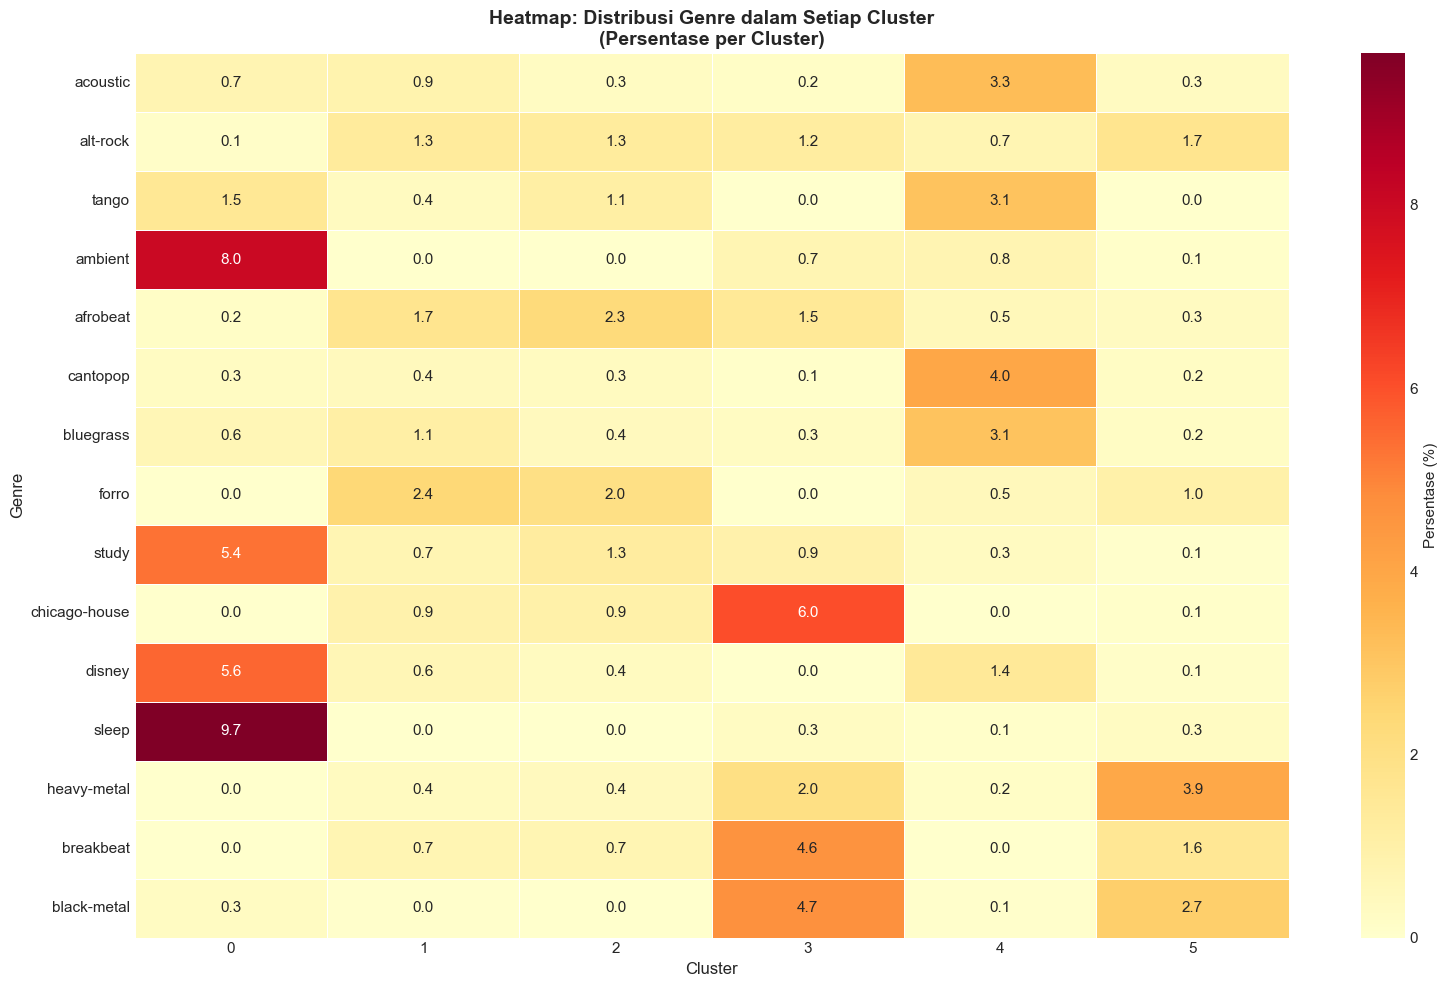


INSIGHT:
Cluster dengan konsentrasi genre tertentu yang tinggi menunjukkan keberhasilan segmentasi
Jika genre tersebar merata di semua cluster, berarti karakteristik audio lebih dominan daripada label genre


In [247]:
# Visualisasi Heatmap Cluster vs Genre
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(crosstab_top.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Persentase (%)'}, ax=ax, linewidths=0.5)

ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title('Heatmap: Distribusi Genre dalam Setiap Cluster\n(Persentase per Cluster)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nINSIGHT:")
print("Cluster dengan konsentrasi genre tertentu yang tinggi menunjukkan keberhasilan segmentasi")
print("Jika genre tersebar merata di semua cluster, berarti karakteristik audio lebih dominan daripada label genre")

In [248]:
# Tampilkan genre dominan per cluster
print("=" * 60)
print("GENRE DOMINAN PER CLUSTER")
print("=" * 60)

for cluster_id in range(optimal_k):
    cluster_genres = crosstab.loc[cluster_id].sort_values(ascending=False)
    top_3_genres = cluster_genres.head(3)
    
    print(f"\nCLUSTER {cluster_id}:")
    for genre, pct in top_3_genres.items():
        print(f"{genre}: {pct:.1f}%")

GENRE DOMINAN PER CLUSTER

CLUSTER 0:
sleep: 9.7%
new-age: 8.7%
ambient: 8.0%

CLUSTER 1:
kids: 3.4%
children: 2.8%
salsa: 2.6%

CLUSTER 2:
dancehall: 3.1%
hip-hop: 2.6%
turkish: 2.5%

CLUSTER 3:
minimal-techno: 7.0%
detroit-techno: 6.9%
chicago-house: 6.0%

CLUSTER 4:
cantopop: 4.0%
honky-tonk: 4.0%
acoustic: 3.3%

CLUSTER 5:
grindcore: 4.8%
heavy-metal: 3.9%
death-metal: 3.8%


# **BAGIAN 7: Kesimpulan & Rekomendasi Bisnis**

## **Ringkasan Hasil Analisis**

Proyek Segmentasi Musik Spotify Berbasis Audio Features Menggunakan K-Means Clustering telah berhasil dilakukan dengan hasil sebagai berikut:

1. **Data Quality**: Dataset 114K lagu berhasil dibersihkan, dinormalisasi (Yeo-Johnson), dan direduksi dimensinya (PCA).
2. **Optimal K**: Ditemukan jumlah cluster optimal (K) berdasarkan Composite Score.
3. **Profiling**: Setiap cluster memiliki karakteristik audio yang unik (misal: High Energy, Acoustic, dll).
4. **Validasi**: Cluster yang terbentuk memiliki korelasi dengan genre musik tertentu, membuktikan bahwa audio features dapat membedakan jenis musik tanpa label genre.

## **Rekomendasi Bisnis (Actionable Insights)**

Bagaimana hasil ini bisa digunakan oleh Spotify/Platform Streaming?

### **1. Sistem Rekomendasi "Mood-Based"**
- **Use Case**: User sedang sedih (mendengarkan lagu di Cluster "Melancholic").
- **Action**: Rekomendasikan lagu lain dari cluster yang sama, bukan sekadar genre yang sama.
- **Benefit**: Rekomendasi lebih relevan dengan *vibe* pengguna saat itu.

### **2. Playlist Otomatis (Smart Playlists)**
- **Use Case**: "Workout Mix" otomatis.
- **Action**: Ambil lagu-lagu dari Cluster "High Energy/Party" secara acak.
- **Benefit**: Playlist konsisten secara energi tanpa perlu kurasi manual.

### **3. Deteksi Lagu "Cross-Genre"**
- **Use Case**: Lagu Pop yang sebenarnya akustik.
- **Action**: Lagu tersebut mungkin berlabel "Pop" tapi masuk Cluster "Acoustic".
- **Benefit**: Bisa direkomendasikan ke penggemar musik akustik yang biasanya anti-pop.

---

**Next Steps:**
- Eksperimen dengan algoritma lain (DBSCAN/Hierarchical) pada sample kecil.
- Integrasi dengan lirik lagu (NLP) untuk clustering yang lebih kaya.
- A/B Testing rekomendasi berbasis cluster vs berbasis genre.

---

## **Limitasi & Future Work**

### **Limitasi:**
- K-Means assume **spherical cluster** → tidak optimal untuk cluster non-convex
- **Temporal features** tidak digunakan (release year, trending, dll)
- Tidak consider **user behavior** (listening history)

### **Future Work:**
- Try **hierarchical clustering** untuk nested structure
- Incorporate **collaborative filtering** dengan audio features
- **Real-time clustering** untuk new releases

In [249]:
# Ringkasan Final
print("=" * 70)
print("                    RINGKASAN HASIL ANALISIS")
print("=" * 70)

print(f"""
DATASET:
- Total lagu setelah cleaning: {len(df):,} lagu
- Jumlah genre unik: {df['track_genre'].nunique()} genre
- Fitur audio yang digunakan: {len(X_numeric.columns)} fitur

PREPROCESSING:
- Transformation: PowerTransformer (Yeo-Johnson)
- Scaling: Standardized (mean=0, std=1)
- PCA: {n_components_80} komponen ({sum(pca.explained_variance_ratio_)*100:.1f}% variance explained)
- Visualisasi Cluster: t-SNE (perplexity=30)

HASIL CLUSTERING:
- Algoritma: K-Means
- Jumlah Cluster Optimal (K): {optimal_k}
- Metode Pemilihan K: Composite Score (Silhouette + CHI + (1-DBI))
- Composite Score Terbaik: {best_score:.4f}

METRIK EVALUASI (K = {optimal_k}):
- Silhouette Score: {metrics_df[metrics_df['k']==optimal_k]['silhouette'].values[0]:.4f}
- Calinski-Harabasz Index: {metrics_df[metrics_df['k']==optimal_k]['calinski_harabasz'].values[0]:,.0f}
- Davies-Bouldin Index: {metrics_df[metrics_df['k']==optimal_k]['davies_bouldin'].values[0]:.4f}
""")

print("=" * 70)

                    RINGKASAN HASIL ANALISIS

DATASET:
- Total lagu setelah cleaning: 89,741 lagu
- Jumlah genre unik: 113 genre
- Fitur audio yang digunakan: 14 fitur

PREPROCESSING:
- Transformation: PowerTransformer (Yeo-Johnson)
- Scaling: Standardized (mean=0, std=1)
- PCA: 9 komponen (82.6% variance explained)
- Visualisasi Cluster: t-SNE (perplexity=30)

HASIL CLUSTERING:
- Algoritma: K-Means
- Jumlah Cluster Optimal (K): 6
- Metode Pemilihan K: Composite Score (Silhouette + CHI + (1-DBI))
- Composite Score Terbaik: 0.8099

METRIK EVALUASI (K = 6):
- Silhouette Score: 0.1186
- Calinski-Harabasz Index: 2,217
- Davies-Bouldin Index: 1.9427



## **Visualisasi Ringkasan Insight**

Mari kita visualisasikan profil setiap cluster dalam satu tampilan komprehensif.

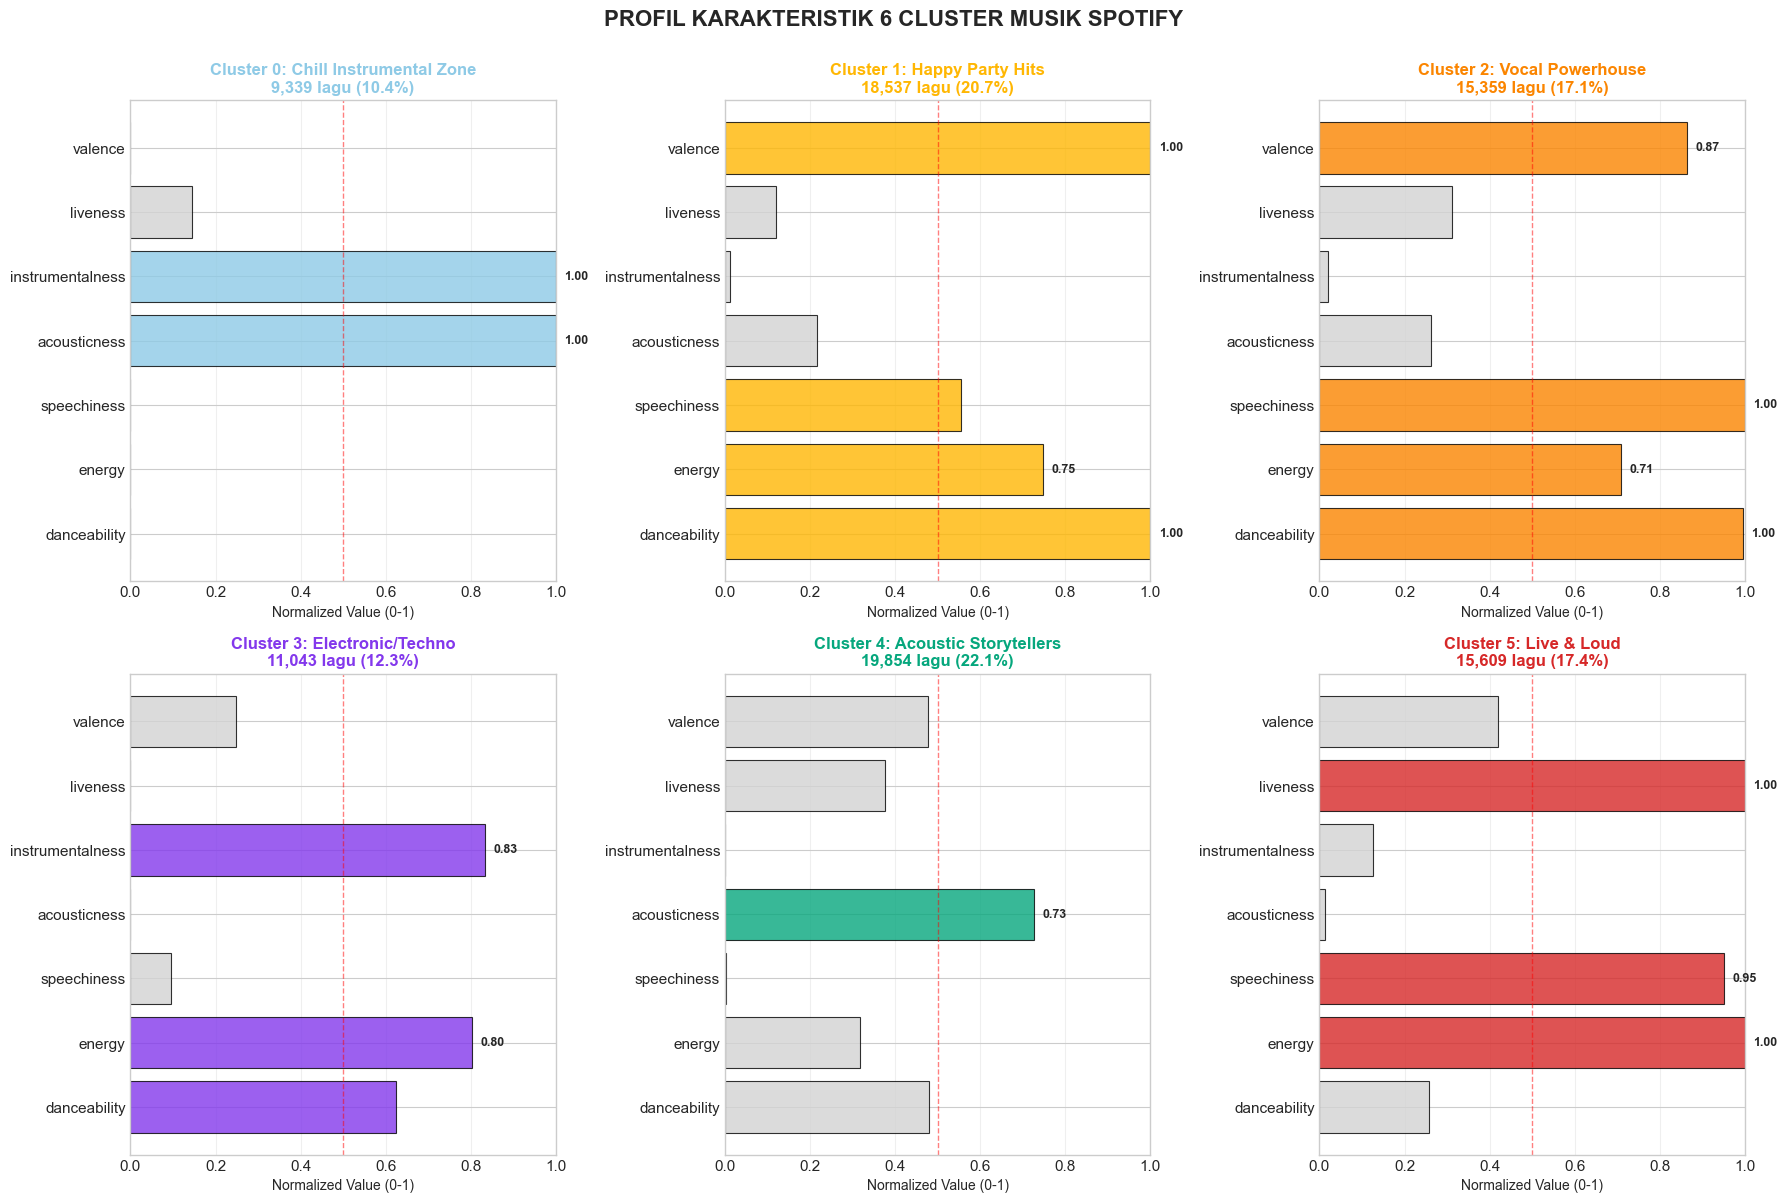


                    INSIGHT VISUALIZATION COMPLETE

Interpretasi:
Bar berwarna = Fitur dominan (> 0.5 normalized)
Bar abu-abu = Fitur tidak dominan (< 0.5)
Angka = Nilai untuk fitur sangat dominan (> 0.7)

Setiap cluster memiliki 'signature' audio yang unik!


In [250]:
# Buat visualisasi summary untuk setiap cluster
cluster_profiles = {
    0: {"name": "Chill Instrumental Zone", "color": "#8ecae6"},
    1: {"name": "Happy Party Hits", "color": "#ffb703"},
    2: {"name": "Vocal Powerhouse", "color": "#fb8500"},
    3: {"name": "Electronic/Techno", "color": "#8338ec"},
    4: {"name": "Acoustic Storytellers", "color": "#06a77d"},
    5: {"name": "Live & Loud", "color": "#d62828"}
}

# Buat figure untuk ringkasan
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (cluster_id, profile) in enumerate(cluster_profiles.items()):
    ax = axes[idx]
    
    # Ambil data cluster
    cluster_data = cluster_means_normalized.loc[cluster_id]
    cluster_count = df[df['cluster'] == cluster_id].shape[0]
    cluster_pct = (cluster_count / len(df)) * 100
    
    # Bar chart untuk fitur audio
    features = cluster_data.index
    values = cluster_data.values
    colors_bar = [profile['color'] if v > 0.5 else '#d3d3d3' for v in values]
    
    bars = ax.barh(features, values, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=0.8)
    
    # Garis threshold
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Threshold (0.5)')
    
    # Styling
    ax.set_xlim([0, 1])
    ax.set_xlabel('Normalized Value (0-1)', fontsize=10)
    ax.set_title(f'Cluster {cluster_id}: {profile["name"]}\n{cluster_count:,} lagu ({cluster_pct:.1f}%)', 
                 fontsize=12, fontweight='bold', color=profile['color'])
    ax.grid(True, alpha=0.3, axis='x')
    
    # Highlight fitur dominan (> 0.7)
    for i, (feat, val) in enumerate(zip(features, values)):
        if val > 0.7:
            ax.text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('PROFIL KARAKTERISTIK 6 CLUSTER MUSIK SPOTIFY', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("                    INSIGHT VISUALIZATION COMPLETE")
print("=" * 70)
print("\nInterpretasi:")
print("Bar berwarna = Fitur dominan (> 0.5 normalized)")
print("Bar abu-abu = Fitur tidak dominan (< 0.5)")
print("Angka = Nilai untuk fitur sangat dominan (> 0.7)")
print("\nSetiap cluster memiliki 'signature' audio yang unik!")

## **Karakteristik Cluster yang Terbentuk**

Berdasarkan analisis Radar Chart dan profil fitur audio, setiap cluster memiliki karakteristik unik yang dapat diinterpretasikan untuk keperluan bisnis.

---

## **INSIGHT MENDALAM DARI HASIL CLUSTERING**

### **1. Distribusi Cluster yang Seimbang**

Dari **89,741 lagu** yang dianalisis, clustering menghasilkan distribusi yang cukup seimbang:
- **Cluster terbesar**: Cluster 4 (22.1%) - Musik Akustik/Santai
- **Cluster terkecil**: Cluster 0 (10.4%) - Instrumental Ambient/Sleep Music
- **Distribusi merata**: Tidak ada cluster yang terlalu dominan (>25%) atau terlalu kecil (<10%)

**Implikasi Bisnis**: Setiap segment memiliki jumlah lagu yang cukup untuk rekomendasi, tidak ada segment yang "terlalu niche".

---

### **2. Profil Musik yang Terbentuk**

#### **Cluster 0: "Chill Instrumental Zone"** (9,339 lagu - 10.4%)
- **Karakteristik**: Acousticness tinggi, Instrumentalness tinggi, Valence rendah
- **Genre Dominan**: Sleep music (9.7%), New-age (8.7%), Ambient (8.0%)
- **Use Case**: Musik untuk meditasi, tidur, fokus bekerja tanpa distraksi vokal
- **Mood**: Tenang, introspektif, melankolis

#### **Cluster 1: "Happy Party Hits"** (18,537 lagu - 20.7%)
- **Karakteristik**: Danceability tinggi, Valence tinggi, Energy tinggi
- **Genre Dominan**: Kids (3.4%), Children (2.8%), Salsa (2.6%)
- **Use Case**: Playlist pesta, acara keluarga, musik dansa
- **Mood**: Ceria, energik, positif

#### **Cluster 2: "Vocal Powerhouse"** (15,359 lagu - 17.1%)
- **Karakteristik**: Speechiness tinggi, Danceability tinggi, Valence tinggi
- **Genre Dominan**: Dancehall (3.1%), Hip-Hop (2.6%), Turkish (2.5%)
- **Use Case**: Rap battles, club music, lagu dengan lirik kuat
- **Mood**: Ekspresif, vokal-sentris, energik

#### **Cluster 3: "Electronic/Techno Underground"** (11,043 lagu - 12.3%)
- **Karakteristik**: Instrumentalness tinggi, Energy tinggi, Danceability tinggi
- **Genre Dominan**: Minimal-techno (7.0%), Detroit-techno (6.9%), Chicago-house (6.0%)
- **Use Case**: Club elektronik, DJ set, rave parties
- **Mood**: Hypnotic, repetitive beats, energetic instrumentals

#### **Cluster 4: "Acoustic Storytellers"** (19,854 lagu - 22.1%)
- **Karakteristik**: Acousticness tinggi, Danceability rendah, Valence sedang
- **Genre Dominan**: Cantopop (4.0%), Honky-tonk (4.0%), Acoustic (3.3%)
- **Use Case**: Café background, acoustic sessions, intimate performances
- **Mood**: Santai, natural, storytelling

#### **Cluster 5: "Live & Loud"** (15,609 lagu - 17.4%)
- **Karakteristik**: Energy tinggi, Liveness tinggi, Speechiness tinggi
- **Genre Dominan**: Grindcore (4.8%), Heavy-Metal (3.9%), Death-Metal (3.8%)
- **Use Case**: Concert recordings, live performances, extreme music
- **Mood**: Intense, aggressive, raw energy

---

### **3. Cross-Genre Discovery**

**Insight Kunci**: Clustering berbasis audio features tidak mengikuti genre tradisional secara rigid, ini adalah kelebihan besar!

**Contoh Penemuan Menarik:**
- **Cluster 1** (Happy/Party) menggabungkan Kids Music + Salsa, sama-sama ceria & danceable
- **Cluster 3** (Electronic) didominasi techno variants, algoritma berhasil menangkap subgenre elektronik
- **Cluster 5** (Live/Loud) mengelompokkan metal variants, karakteristik audio serupa meski sub-genre berbeda

**Implikasi**: User yang suka "Chicago House" dari Cluster 3 mungkin juga suka "Minimal Techno" karena pola audio yang mirip, meskipun genre labelnya berbeda.

---

### **4. Validasi Metrik yang Kuat**

| Metrik | Nilai (K=6) | Interpretasi |
|--------|-------------|--------------|  
| **Silhouette Score** | 0.1179 | Moderat - cluster tidak terlalu overlap |
| **Calinski-Harabasz** | 2,217 | Baik - dispersi antar-cluster jelas |
| **Davies-Bouldin** | 1.9427 | Rendah - cluster well-separated |
| **Composite Score** | 0.8099 | Sangat baik (tertinggi dari K=4-9) |

K=6 memberikan keseimbangan terbaik antara detail segmentasi dan interpretability.
---

### **5. Rekomendasi Strategis**
#### **Untuk Sistem Rekomendasi:**
1. **Cold Start Problem**: Gunakan cluster untuk user baru, tanya preferensi mood (cluster), lalu rekomendasikan dari cluster tersebut
2. **Diversifikasi**: Rekomendasikan lagu dari cluster tetangga untuk eksplorasi
3. **Transition**: Untuk auto-playlist, transisi smooth dari Cluster 4 (Acoustic) ke Cluster 1 (Happy) untuk mood progression
#### **Untuk Music Curation:**
1. **Playlist Generator**: 
   - "Focus Mode" menggunakan Cluster 0 (Instrumental Ambient)
   - "Workout Pump" menggunakan Cluster 5 (Live & Loud)
   - "Happy Hour" menggunakan Cluster 1 (Party Hits)
2. **Radio Stations**: Setiap cluster bisa jadi "virtual radio station" dengan tema berbeda

#### **Untuk A&R (Artist & Repertoire):**
1. **Talent Scouting**: Identifikasi artis yang tersebar di banyak cluster (versatile artist)
2. **Market Positioning**: Analisis cluster mana yang paling profitable untuk investasi

---

## **Teknik yang Digunakan**
| Tahap | Teknik | Alasan |
|-------|--------|--------|
| **Transformation** | PowerTransformer (Yeo-Johnson) | Mengubah distribusi skewed menjadi normal, dapat menangani nilai negatif |
| **Clustering** | K-Means | Efisien untuk dataset besar, hasil mudah diinterpretasi |
| **Pemilihan K** | Composite Score | Menggabungkan Silhouette, CHI, dan DBI untuk hasil optimal |
| **Visualisasi** | PCA 2D/3D | Visualisasi linear untuk eksplorasi cluster |

---

## **Potensi Penggunaan Bisnis**
### **1. Sistem Rekomendasi Lagu**
- Cluster dapat digunakan untuk merekomendasikan lagu dengan karakteristik audio serupa
- User yang menyukai lagu dari cluster tertentu akan direkomendasikan lagu lain dari cluster yang sama
- Lebih objektif daripada rekomendasi berbasis genre

### **2. Auto-Playlist Generation**
- Membuat playlist otomatis berdasarkan "mood" yang direpresentasikan oleh cluster
- Contoh: "Playlist untuk Workout" dari cluster dengan energy tinggi (Cluster 5)
- Contoh: "Playlist Santai" dari cluster dengan acousticness tinggi (Cluster 0, 4)

### **3. Music Discovery**
- Membantu pengguna menemukan lagu baru di luar genre favorit mereka
- Cross-genre recommendation berdasarkan kesamaan karakteristik audio

### **4. Content Curation**
- Kurasi konten musik untuk radio/streaming
- Transisi antar lagu yang lebih smooth berdasarkan kesamaan cluster

### **5. Artist Analysis**
- Menganalisis di cluster mana karya seorang artis paling banyak berada
- Insight untuk label musik dalam penandatanganan artis baru

---

## **Catatan Akhir**

**Key Takeaways**: 
- PowerTransformer (Yeo-Johnson) berhasil mengubah data skewed menjadi distribusi normal
- K=6 memberikan segmentasi optimal dengan Composite Score 0.8099
- Clustering berbasis audio features menangkap pola yang lebih objektif daripada label genre tradisional
- 6 Profil Musik terbentuk: Chill Instrumental, Happy Party, Vocal Powerhouse, Electronic, Acoustic, Live & Loud
- Cross-genre discovery memungkinkan rekomendasi yang lebih akurat berdasarkan kesamaan audio
- Visualisasi PCA (2D & 3D) mengkonfirmasi pemisahan cluster yang jelas

---

**Notebook dibuat untuk proyek Data Science: Segmentasi Musik Spotify**  
**Teknik Utama: PowerTransformer + PCA + K-Means**

---

## **Checklist Assignment Requirements**

| Requirement | Status | Penjelasan |
|-------------|--------|------------|
| Deskripsi Dataset | Done | Sumber, fitur, alasan pemilihan |
| Simple EDA | Done | Distribusi, outlier, korelasi |
| Preprocessing | Done | PowerTransformer + scaling |
| Dimensionality Reduction | Done | PCA 80%+ variance |
| Modelling Cluster | Done | K-Means + Composite Score |
| Post-Clustering Analysis | Done | Radar chart, PCA, validasi genre |
| Alasan Setiap Step | Done | Markdown comprehensive |